# Exploratory Data Analysis

# Personal Information
**Name:** Asal Mehrabi  
**Student ID:** 16209680

**Email:** [asal.mehrabi@student.uva.nl](mailto:asal.mehrabi@student.uva.nl)  
**Date:** 23.03.2026
**Repository**: [Github repository](https://github.com/asalmehrabi/LLMaaJ-Prompting.git)

# Data Context

This exploratory data analysis investigates the datasets that will be used for the thesis related to prompting strategies for LLM-as-a-Judge evaluation across multilingual scenarios(African, European, and Middle Eastern languages). The central question is whether prompting strategy choice (zero-shot, few-shot, chain-of-thought, rubric-based) affects judge reliability differently across languages with different resource levels, scripts, and morphological properties.

To address different research questions the following datasets are chosen, divided into two evaluation modes. The selection covers 3 script families (Latin, Ethiopic, Arabic), 4 resource levels (high, mid, low-mid, low), and 6 NLP task types across Africa, Europe, and the Middle East. Grounded in Gu et al. (2025) evaluation scenarios A (verification), B (quality rating), and C (model output evaluation).

## LLM-as-a-Judge Evaluation (5 datasets)

These tasks require **subjective or open-ended evaluation**, where automatic metrics (e.g., BLEU, ROUGE, exact match) are insufficient. The LLM acts as a *judge* to assess output quality.

| Dataset | Task | Key Properties |
|--------|------|---------------|
| **FLORES-200** (NLLB Team, 2024) | Machine Translation | Large parallel corpus (200+ languages); enables controlled cross-lingual comparison |
| **MAFAND-MT** (Adelani et al., 2022) | Machine Translation | African-focused; low-resource languages; news domain |
| **XL-Sum** (Hasan et al., 2021) | Summarization | Abstractive summaries; ROUGE weakly correlates with human judgment |
| **AfriQA** (Ogundepo et al., 2023) | Question Answering | Free-text answers; requires semantic equivalence evaluation |
| **AfriMGSM** (Adelani et al., 2024) | Mathematical Reasoning | Step-by-step reasoning; evaluation requires process-level judgment |

**Rationale:**  
These datasets cover **generation-heavy tasks** where in the evaluation fase we see:

- semantic adequacy  
- fluency and naturalness  
- reasoning correctness  
- partial correctness  

This makes them ideal for testing LLM-as-a-Judge reliability under different prompting strategies.

## Task Capability Evaluation (4 datasets)

These datasets use **structured outputs with gold labels**, allowing direct evaluation without a judge. They serve as a **control setting** to isolate the effect of prompting on task performance.

| Dataset | Task | Key Properties |
|--------|------|---------------|
| **MasakhaNEWS** (Adelani et al., 2023) | News Classification | 7 balanced classes; 13 African languages |
| **AfriSenti** (Muhammad et al., 2023) | Sentiment Analysis | Social media domain; class imbalance |
| **AfriXNLI** (Adelani et al., 2024) | Natural Language Inference | 16 languages; balanced labels |
| **Belebele** (Bandarkar et al., 2024) | Reading Comprehension (MC) | Fully parallel across languages |

**Rationale:**  
These tasks provide objective ground truth labels, avoid evaluation ambiguity and allows us to perform comparison between model performance and judge-based evaluation. 

It is mentionable that **NLI is excluded from judge-based evaluation** due to circularity, as the judge would need to perform the same inference task as the model itself.

# Data Description

### 0. Setup

**Version requirement:** MasakhaNEWS, MAFAND-MT, AfriQA, AfriMGSM, AfriXNLI, and AfriSenti use HuggingFace loading scripts requiring `datasets==2.20.0`. FLORES-200, Belebele, and XL-Sum use Parquet and work with any version. Run once; restart runtime if on Colab.

In [43]:
from IPython.display import HTML

HTML("""
<style>

/* ── General text ───────────────────────── */
body, .jp-Notebook, .rendered_html {
    font-size: 9px !important;
    line-height: 1.3 !important;
}

/* ── Headings (FIX BIG TITLES) ─────────── */
.rendered_html h1 { font-size: 14px !important; }
.rendered_html h2 { font-size: 12px !important; }
.rendered_html h3 { font-size: 11px !important; }
.rendered_html h4 { font-size: 10px !important; }
.rendered_html h5 { font-size: 9px !important; }
.rendered_html h6 { font-size: 8px !important; }

/* ── Code (readable) ───────────────────── */
div.input_area pre,
div.input_area code,
.jp-CodeCell .cm-content,
.jp-InputArea-editor,
div.output_area pre,
div.output_area code {
    font-size: 9px !important;
    line-height: 1.3 !important;
}

/* ── Tables (FIX BIG TABLE TEXT) ───────── */
.dataframe, table {
    font-size: 6px !important;
    width: 100% !important;
    table-layout: auto !important;
}

/* Headers smaller + bold */
.dataframe th, table th {
    font-size: 6px !important;
    font-weight: 600 !important;
    padding: 2px 3px !important;
}

/* Cells */
.dataframe td, table td {
    font-size: 6px !important;
    padding: 2px 3px !important;
    white-space: normal !important;
    word-break: break-word !important;
}

/* ── Outputs scroll nicely ─────────────── */
.output_area, .output, .jp-OutputArea-output {
    overflow-x: auto !important;
    max-width: 100% !important;
}

/* ── Print optimization ────────────────── */
@media print {

    body {
        font-size: 8px !important;
    }

    .rendered_html h1 { font-size: 12px !important; }
    .rendered_html h2 { font-size: 10px !important; }
    .rendered_html h3 { font-size: 9px !important; }

    pre, code {
        font-size: 7px !important;
        line-height: 1.2 !important;
        white-space: pre-wrap !important;
    }

    .dataframe, table {
        font-size: 5.5px !important;
    }

    table {
        page-break-inside: avoid !important;
    }
}

</style>
""")

In [17]:
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "datasets==2.20.0", "pandas>=2.0", "matplotlib>=3.7",
    "seaborn>=0.13", "plotly>=5.18", "scipy>=1.11", "ipywidgets",
])
print("Installation complete.")

Installation complete.


In [18]:
import os, ast, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datasets import load_dataset

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})
SEED = 42
np.random.seed(SEED)
print("All imports successful")

All imports successful


### Data Loading

**Language and dataset coverage — 9 datasets, 20+ languages:**

| Language | Script | Resource | FLORES | MAFAND | XL-Sum | AfriQA | AfriMGSM | NEWS | Senti | AfriXNLI | Belebele |
|---|---|---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| English | Latin | High | ✓ | | | | | | | ✓ | ✓ |
| French | Latin | High | ✓ | | | | | ✓ | | ✓ | ✓ |
| Catalan | Latin | Mid | ✓ | | | | | | | | ✓ |
| Persian | Arabic | Mid | ✓ | | | | | | | | ✓ |
| Hausa | Latin | Low-mid | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| Swahili | Latin | Low-mid | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| Yoruba | Latin | Low | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| Amharic | Ethiopic | Low | ✓ | ✓ | ✓ | | ✓ | ✓ | ✓ | ✓ | ✓ |
| Igbo | Latin | Low | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| Kinyarwanda | Latin | Low | ✓ | ✓ | | ✓ | ✓ | | ✓ | ✓ | |
| Nigerian Pidgin | Latin | Low | | ✓ | ✓ | | | ✓ | ✓ | ✓ | |
| Xhosa | Latin | Low | ✓ | ✓ | | | ✓ | ✓ | | ✓ | ✓ |
| Zulu | Latin | Low | ✓ | ✓ | | | ✓ | | | ✓ | ✓ |
| Twi | Latin | Low | | ✓ | | ✓ | | | ✓ | ✓ | |
| Luganda | Latin | Low | | ✓ | | | ✓ | ✓ | | ✓ | |
| Ewe | Latin | Low | | ✓ | | | ✓ | | | ✓ | |
| Wolof | Latin | Low | | ✓ | | | ✓ | | | ✓ | |
| Oromo | Latin | Low | | | ✓ | | ✓ | ✓ | ✓ | ✓ | |
| Somali | Latin | Low | | | ✓ | | | ✓ | | ✓ | |
| Tigrinya | Ethiopic | Low | | | ✓ | | | | ✓ | ✓ | |
| Moroccan Arabic | Arabic | Low | | | | | | | ✓ | ✓ | |

**Swahili** appears in all 9 datasets — primary anchor for cross-task analysis (RQ1).  
**Hausa, Yoruba, Igbo** appear in all 9 datasets — secondary anchors.  
**Amharic** appears in 8 datasets.

In [19]:
# lang_code -> (display_name, script, resource_level, region)
LANG_META = {
    # Short codes — Masakhane datasets
    "fra": ("French",          "Latin",    "high",    "Europe"),
    "hau": ("Hausa",           "Latin",    "low-mid", "West Africa"),
    "swa": ("Swahili",         "Latin",    "low-mid", "East Africa"),
    "yor": ("Yoruba",          "Latin",    "low",     "West Africa"),
    "amh": ("Amharic",         "Ethiopic", "low",     "East Africa"),
    "xho": ("Xhosa",           "Latin",    "low",     "Southern Africa"),
    "zul": ("Zulu",            "Latin",    "low",     "Southern Africa"),
    "kin": ("Kinyarwanda",     "Latin",    "low",     "Central Africa"),
    "pcm": ("Nigerian Pidgin", "Latin",    "low",     "West Africa"),
    "ibo": ("Igbo",            "Latin",    "low",     "West Africa"),
    "twi": ("Twi",             "Latin",    "low",     "West Africa"),
    "lug": ("Luganda",         "Latin",    "low",     "East Africa"),
    "ewe": ("Ewe",             "Latin",    "low",     "West Africa"),
    "wol": ("Wolof",           "Latin",    "low",     "West Africa"),
    "som": ("Somali",          "Latin",    "low",     "East Africa"),
    "orm": ("Oromo",           "Latin",    "low",     "East Africa"),
    "tir": ("Tigrinya",        "Ethiopic", "low",     "East Africa"),
    "ary": ("Moroccan Arabic", "Arabic",   "low",     "North Africa"),
    "lin": ("Lingala",         "Latin",    "low",     "Central Africa"),
    "sna": ("Shona",           "Latin",    "low",     "Southern Africa"),
    "sot": ("Sotho",           "Latin",    "low",     "Southern Africa"),
    "run": ("Rundi",           "Latin",    "low",     "Central Africa"),
    "bem": ("Bemba",           "Latin",    "low",     "Southern Africa"),
    "fon": ("Fon",             "Latin",    "low",     "West Africa"),
    # XNLI short codes
    "en":  ("English",         "Latin",    "high",    "Global"),
    "fr":  ("French",          "Latin",    "high",    "Europe"),
    "sw":  ("Swahili",         "Latin",    "low-mid", "East Africa"),
    # FLORES / Belebele codes
    "eng_Latn": ("English",  "Latin",    "high",    "Global"),
    "fra_Latn": ("French",   "Latin",    "high",    "Europe"),
    "cat_Latn": ("Catalan",  "Latin",    "mid",     "Europe"),
    "pes_Arab": ("Persian",  "Arabic",   "mid",     "Middle East"),
    "hau_Latn": ("Hausa",    "Latin",    "low-mid", "West Africa"),
    "swh_Latn": ("Swahili",  "Latin",    "low-mid", "East Africa"),
    "yor_Latn": ("Yoruba",   "Latin",    "low",     "West Africa"),
    "amh_Ethi": ("Amharic",  "Ethiopic", "low",     "East Africa"),
    "ibo_Latn": ("Igbo",     "Latin",    "low",     "West Africa"),
    "kin_Latn": ("Kinyarwanda","Latin",  "low",     "Central Africa"),
    "xho_Latn": ("Xhosa",    "Latin",    "low",     "Southern Africa"),
    "zul_Latn": ("Zulu",     "Latin",    "low",     "Southern Africa"),
    # AfriXNLI English
    "eng":  ("English",         "Latin",    "high",    "Global"),
}

RESOURCE_COLORS = {"high": "#1D9E75", "mid": "#EF9F27", "low-mid": "#D85A30", "low": "#993C1D"}
SCRIPT_COLORS   = {"Latin": "#534AB7", "Arabic": "#D85A30", "Ethiopic": "#1D9E75"}

# ── Dataset-specific language lists ──────────────────────────────────────────
FLORES_LANGS   = ["eng_Latn","fra_Latn","cat_Latn","pes_Arab",
                   "hau_Latn","swh_Latn","yor_Latn","amh_Ethi",
                   "ibo_Latn","kin_Latn","xho_Latn","zul_Latn"]  # 12

# MAFAND uses "en-{lang}" config keys; target language code is after the dash
MAFAND_PAIRS   = ["en-hau","en-swa","en-yor","en-amh","en-ibo",
                   "en-kin","en-pcm","en-xho","en-zul","en-twi",
                   "en-lug","en-sna"]  # 15

XLSUM_LANGS    = ["hausa","yoruba","amharic","swahili",
                   "igbo","somali","oromo","pidgin","tigrinya"]  # 9
XLSUM_CODE_MAP = {"hausa":"hau","yoruba":"yor","amharic":"amh","swahili":"swa",
                   "igbo":"ibo","somali":"som","oromo":"orm","pidgin":"pcm",
                   "tigrinya":"tir"}


QA_LANGS       = ["hau","swa","yor","zul","kin","ibo","twi","bem","fon"]  # 9

AFRIMGSM_LANGS = ["hau","swa","yor","amh","ibo","kin","lug",
                   "xho","zul","ewe","lin","orm","sot","wol"]  # 14

NEWS_LANGS     = ["fra","hau","swa","yor","amh","xho","ibo",
                   "lug","orm","som","sna","pcm","run"]  # 13

AFRISENTI_LANGS= ["hau","swa","yor","amh","pcm","kin","ibo",
                   "twi","orm","tir","ary"]  # 11

AFRIXNLI_LANGS = ["eng","hau","swa","yor","amh","ibo","kin",
                   "xho","zul","twi","lug","pcm",
                   "ewe","lin","orm","sot"]  # 16

BELEBELE_LANGS = ["eng_Latn","fra_Latn","cat_Latn","pes_Arab",
                   "hau_Latn","swh_Latn","yor_Latn","amh_Ethi",
                   "ibo_Latn","xho_Latn","zul_Latn","kin_Latn",
                   "som_Latn","wol_Latn"]  # 14
# Add missing Belebele codes
LANG_META["som_Latn"] = ("Somali",  "Latin", "low", "East Africa")
LANG_META["wol_Latn"] = ("Wolof",   "Latin", "low", "West Africa")
LANG_META["orm_Latn"] = ("Oromo",   "Latin", "low", "East Africa")

NEWS_LABELS   = ["business","entertainment","health","politics",
                  "religion","sports","technology"]
NLI_LABELS    = {0:"entailment",1:"neutral",2:"contradiction"}
SENTI_LABELS  = ["positive","neutral","negative"]
HATE_LABELS   = ["hate","abusive","normal"]

print("Configuration loaded:")
for name, lst in [("FLORES-200",FLORES_LANGS),("MAFAND-MT",MAFAND_PAIRS),
                   ("XL-Sum",XLSUM_LANGS),("AfriQA",QA_LANGS),("AfriMGSM",AFRIMGSM_LANGS),
                   ("MasakhaNEWS",NEWS_LANGS),("AfriSenti",AFRISENTI_LANGS),
                   ("AfriXNLI",AFRIXNLI_LANGS),("Belebele",BELEBELE_LANGS)]:
    print(f"  {name:15s} ({len(lst):2d}): {lst}")

Configuration loaded:
  FLORES-200      (12): ['eng_Latn', 'fra_Latn', 'cat_Latn', 'pes_Arab', 'hau_Latn', 'swh_Latn', 'yor_Latn', 'amh_Ethi', 'ibo_Latn', 'kin_Latn', 'xho_Latn', 'zul_Latn']
  MAFAND-MT       (12): ['en-hau', 'en-swa', 'en-yor', 'en-amh', 'en-ibo', 'en-kin', 'en-pcm', 'en-xho', 'en-zul', 'en-twi', 'en-lug', 'en-sna']
  XL-Sum          ( 9): ['hausa', 'yoruba', 'amharic', 'swahili', 'igbo', 'somali', 'oromo', 'pidgin', 'tigrinya']
  AfriQA          ( 9): ['hau', 'swa', 'yor', 'zul', 'kin', 'ibo', 'twi', 'bem', 'fon']
  AfriMGSM        (14): ['hau', 'swa', 'yor', 'amh', 'ibo', 'kin', 'lug', 'xho', 'zul', 'ewe', 'lin', 'orm', 'sot', 'wol']
  MasakhaNEWS     (13): ['fra', 'hau', 'swa', 'yor', 'amh', 'xho', 'ibo', 'lug', 'orm', 'som', 'sna', 'pcm', 'run']
  AfriSenti       (11): ['hau', 'swa', 'yor', 'amh', 'pcm', 'kin', 'ibo', 'twi', 'orm', 'tir', 'ary']
  AfriXNLI        (16): ['eng', 'hau', 'swa', 'yor', 'amh', 'ibo', 'kin', 'xho', 'zul', 'twi', 'lug', 'pcm', 'ewe', 'lin

### Loading: FLORES-200
Parallel corpus — same content across all 12 language variants. No `trust_remote_code` needed. 
Splits: `dev` (997) + `devtest` (1012).

In [20]:
# ── FLORES-200 ────────────────────────────────────────────────────────────────
# HuggingFace: Muennighoff/flores200 | Cite: NLLB Team (2024)
# Mode: LLM-as-a-Judge (Scenario B: MT quality rating)
print("Loading FLORES-200...")
flores_dfs = {}
for code_ in FLORES_LANGS:
    try:
        ds = load_dataset("Muennighoff/flores200", code_, trust_remote_code=True)
        df = pd.concat([ds[s].to_pandas().assign(split=s) for s in ds.keys()], ignore_index=True)
        meta = LANG_META[code_]
        df["lang_code"] = code_
        df["language"]  = meta[0]
        df["script"]    = meta[1]
        df["resource"]  = meta[2]
        if "sentence" in df.columns and "text" not in df.columns:
            df = df.rename(columns={"sentence": "text"})
        flores_dfs[code_] = df
        print(f"  {code_} ({meta[0]}): {len(df):,} rows")
    except Exception as e:
        print(f"  {code_} FAILED: {e}")
df_flores = pd.concat(flores_dfs.values(), ignore_index=True)
print(f"\nFLORES-200: {len(df_flores):,} rows, {df_flores['language'].nunique()} languages")

Loading FLORES-200...
  eng_Latn (English): 2,009 rows
  fra_Latn (French): 2,009 rows
  cat_Latn (Catalan): 2,009 rows
  pes_Arab (Persian): 2,009 rows
  hau_Latn (Hausa): 2,009 rows
  swh_Latn (Swahili): 2,009 rows
  yor_Latn (Yoruba): 2,009 rows
  amh_Ethi (Amharic): 2,009 rows
  ibo_Latn (Igbo): 2,009 rows
  kin_Latn (Kinyarwanda): 2,009 rows
  xho_Latn (Xhosa): 2,009 rows
  zul_Latn (Zulu): 2,009 rows

FLORES-200: 24,108 rows, 12 languages


### Loading: MAFAND-MT
News-domain MT. Config keys are `en-{lang}`. Translation column is a dict `{"en": ..., "tgt": ...}`.

In [21]:
# ── MAFAND-MT ─────────────────────────────────────────────────────────────────
# HuggingFace: masakhane/mafand | Cite: Adelani et al. (2022)
# Mode: LLM-as-a-Judge (Scenario B: MT quality rating)
print("Loading MAFAND-MT...")
mafand_dfs = {}
for pair in MAFAND_PAIRS:
    tgt = pair.split("-")[1]
    try:
        ds = load_dataset("masakhane/mafand", pair, trust_remote_code=True)
        df = pd.concat([ds[s].to_pandas().assign(split=s) for s in ds.keys()], ignore_index=True)
        # translation column is a dict; extract source and target
        df["source_en"] = df["translation"].apply(lambda x: x.get("en","") if isinstance(x,dict) else "")
        df["target"]    = df["translation"].apply(lambda x: x.get(tgt,"") if isinstance(x,dict) else "")
        df["text"]      = df["target"]  # main text for length / TTR analysis
        meta = LANG_META.get(tgt, (tgt, "Latin", "low", "Africa"))
        df["language"]  = tgt
        df["lang_name"] = meta[0]
        df["script"]    = meta[1]
        df["resource"]  = meta[2]
        mafand_dfs[tgt] = df
        print(f"  {pair} ({meta[0]}): {len(df):,} rows")
    except Exception as e:
        print(f"  {pair} FAILED: {e}")
df_mafand = pd.concat(mafand_dfs.values(), ignore_index=True)
print(f"\nMAFAND-MT: {len(df_mafand):,} rows, {df_mafand['language'].nunique()} languages")

Loading MAFAND-MT...
  en-hau (Hausa): 8,665 rows
  en-swa (Swahili): 34,408 rows
  en-yor (Yoruba): 9,746 rows
  en-amh (Amharic): 1,936 rows
  en-ibo (Igbo): 9,998 rows
  en-kin (Kinyarwanda): 1,466 rows
  en-pcm (Nigerian Pidgin): 7,838 rows
  en-xho (Xhosa): 1,488 rows
  en-zul (Zulu): 5,737 rows
  en-twi (Twi): 6,121 rows
  en-lug (Luganda): 7,075 rows
  en-sna (Shona): 1,561 rows

MAFAND-MT: 96,039 rows, 12 languages


### Loading: XL-Sum
BBC article–summary pairs. Test split only. Uses full language names (e.g. `"hausa"`).

In [22]:
# ── XL-Sum ────────────────────────────────────────────────────────────────────
# HuggingFace: csebuetnlp/xlsum | Cite: Hasan et al. (2021)
# Mode: LLM-as-a-Judge (Scenario B: summarization quality rating)
# Most natural judge task: ROUGE correlates poorly with human quality judgments
print("Loading XL-Sum (test split only)...")
xlsum_dfs = {}
for lang_name in XLSUM_LANGS:
    try:
        ds = load_dataset("csebuetnlp/xlsum", lang_name, split="test", trust_remote_code=True)
        df = ds.to_pandas().assign(split="test")
        short = XLSUM_CODE_MAP.get(lang_name, lang_name)
        meta  = LANG_META.get(short, (lang_name, "Latin", "low", "Africa"))
        df["language"]          = short
        df["lang_name"]         = meta[0]
        df["script"]            = meta[1]
        df["resource"]          = meta[2]
        df["article_len_words"] = df["text"].str.split().str.len()
        df["summary_len_words"] = df["summary"].str.split().str.len()
        xlsum_dfs[short] = df
        print(f"  {lang_name} ({meta[0]}): {len(df):,} rows")
    except Exception as e:
        print(f"  {lang_name} FAILED: {e}")
df_xlsum = pd.concat(xlsum_dfs.values(), ignore_index=True)
print(f"\nXL-Sum: {len(df_xlsum):,} rows, {df_xlsum['language'].nunique()} languages")

Loading XL-Sum (test split only)...
  hausa (Hausa): 802 rows
  yoruba (Yoruba): 793 rows
  amharic (Amharic): 719 rows
  swahili (Swahili): 987 rows
  igbo (Igbo): 522 rows
  somali (Somali): 745 rows
  oromo (Oromo): 757 rows
  pidgin (Nigerian Pidgin): 1,151 rows
  tigrinya (Tigrinya): 681 rows

XL-Sum: 7,157 rows, 9 languages


### Loading: AfriQA
Cross-lingual open-retrieval QA. 100% human-translated. 28.8% unanswerable.

In [23]:
# ── AfriQA ────────────────────────────────────────────────────────────────────
# HuggingFace: masakhane/afriqa | Cite: Ogundepo et al. (2023)
# Mode: LLM-as-a-Judge (Scenario A + C: answer verification)
def safe_parse_answers(val):
    if isinstance(val, list): return val
    try: return ast.literal_eval(str(val))
    except Exception:
        matches = re.findall(r"'([^']*)'|\"([^\"]*)\"", str(val))
        return [m[0] or m[1] for m in matches] if matches else [str(val)]

print("Loading AfriQA...")
qa_dfs = {}
for lang in QA_LANGS:
    try:
        ds = load_dataset("masakhane/afriqa", lang, trust_remote_code=True)
        df = pd.concat([ds[s].to_pandas().assign(split=s) for s in ds.keys()], ignore_index=True)
        meta = LANG_META.get(lang, (lang, "Latin", "low", "Africa"))
        df["language"]       = lang
        df["lang_name"]      = meta[0]
        df["script"]         = meta[1]
        df["resource"]       = meta[2]
        df["answers_parsed"] = df["answers"].apply(safe_parse_answers)
        df["n_gold_answers"] = df["answers_parsed"].apply(len)
        qa_dfs[lang] = df
        print(f"  {lang} ({meta[0]}): {len(df):,} rows")
    except Exception as e:
        print(f"  {lang} FAILED: {e}")
df_qa = pd.concat(qa_dfs.values(), ignore_index=True)
print(f"\nAfriQA: {len(df_qa):,} rows, {df_qa['language'].nunique()} languages")

Loading AfriQA...
  hau (Hausa): 1,171 rows
  swa (Swahili): 1,134 rows
  yor (Yoruba): 1,053 rows
  zul (Zulu): 1,100 rows
  kin (Kinyarwanda): 1,163 rows
  ibo (Igbo): 1,244 rows
  twi (Twi): 1,393 rows
  bem (Bemba): 1,319 rows
  fon (Fon): 1,241 rows

AfriQA: 10,818 rows, 9 languages


### Loading: AfriMGSM (IrokoBench)
Math reasoning — judge evaluates step-by-step chains, not just final answer. AfroBench: +4.9 with few-shot.

In [24]:
# ── AfriMGSM ──────────────────────────────────────────────────────────────────
# HuggingFace: masakhane/afrimgsm | Cite: Adelani et al. (2024)
# Mode: LLM-as-a-Judge (Scenario A + B: reasoning step verification)
# CoT for judge directly mirrors CoT for the model — core methodological parallel
print("Loading AfriMGSM...")
mgsm_dfs = {}
for lang in AFRIMGSM_LANGS:
    try:
        ds = load_dataset("masakhane/afrimgsm", lang, trust_remote_code=True)
        df = pd.concat([ds[s].to_pandas().assign(split=s) for s in ds.keys()], ignore_index=True)
        meta = LANG_META.get(lang, (lang, "Latin", "low", "Africa"))
        df["language"]  = lang
        df["lang_name"] = meta[0]
        df["script"]    = meta[1]
        df["resource"]  = meta[2]
        df["text"]      = df["question"] if "question" in df.columns else df.iloc[:,0]
        mgsm_dfs[lang]  = df
        print(f"  {lang} ({meta[0]}): {len(df):,} rows")
    except Exception as e:
        print(f"  {lang} FAILED: {e}")
df_mgsm = pd.concat(mgsm_dfs.values(), ignore_index=True)
print(f"\nAfriMGSM: {len(df_mgsm):,} rows, {df_mgsm['language'].nunique()} languages")

Loading AfriMGSM...
  hau (Hausa): 258 rows
  swa (Swahili): 258 rows
  yor (Yoruba): 258 rows
  amh (Amharic): 258 rows
  ibo (Igbo): 258 rows
  kin (Kinyarwanda): 258 rows
  lug (Luganda): 258 rows
  xho (Xhosa): 258 rows
  zul (Zulu): 258 rows
  ewe (Ewe): 258 rows
  lin (Lingala): 258 rows
  orm (Oromo): 258 rows
  sot (Sotho): 258 rows
  wol (Wolof): 258 rows

AfriMGSM: 3,612 rows, 14 languages


### Loading: MasakhaNEWS
Task capability — 7-class news classification. Prompting strategies tested on LLM directly.

In [25]:
# ── MasakhaNEWS ───────────────────────────────────────────────────────────────
# HuggingFace: masakhane/masakhanews | Cite: Adelani et al. (2023)
# Mode: Task Capability
print("Loading MasakhaNEWS...")
news_dfs = {}
for lang in NEWS_LANGS:
    try:
        ds = load_dataset("masakhane/masakhanews", lang, trust_remote_code=True)
        df = pd.concat([ds[s].to_pandas().assign(split=s) for s in ds.keys()], ignore_index=True)
        meta = LANG_META.get(lang, (lang, "Latin", "low", "Africa"))
        df["language"]   = lang
        df["lang_name"]  = meta[0]
        df["script"]     = meta[1]
        df["resource"]   = meta[2]
        df["label_name"] = df["category"]
        news_dfs[lang]   = df
        print(f"  {lang} ({meta[0]}): {len(df):,} rows")
    except Exception as e:
        print(f"  {lang} FAILED: {e}")
df_news = pd.concat(news_dfs.values(), ignore_index=True)
print(f"\nMasakhaNEWS: {len(df_news):,} rows, {df_news['language'].nunique()} languages")

Loading MasakhaNEWS...
  fra (French): 2,109 rows
  hau (Hausa): 3,173 rows
  swa (Swahili): 2,371 rows
  yor (Yoruba): 2,050 rows
  amh (Amharic): 1,875 rows
  xho (Xhosa): 1,476 rows
  ibo (Igbo): 1,940 rows
  lug (Luganda): 1,104 rows
  orm (Oromo): 1,615 rows
  som (Somali): 1,463 rows
  sna (Shona): 1,842 rows
  pcm (Nigerian Pidgin): 1,517 rows
  run (Rundi): 1,598 rows

MasakhaNEWS: 24,133 rows, 13 languages


### Loading: AfriSenti
Task capability — Twitter sentiment analysis, 11 African languages.

In [26]:
# ── AfriSenti ─────────────────────────────────────────────────────────────────
# HuggingFace: masakhane/afrisenti | Cite: Muhammad et al. (2023)
# Mode: Task Capability
print("Loading AfriSenti...")
senti_dfs = {}
for lang in AFRISENTI_LANGS:
    try:
        ds = load_dataset("masakhane/afrisenti", lang, trust_remote_code=True)
        df = pd.concat([ds[s].to_pandas().assign(split=s) for s in ds.keys()], ignore_index=True)
        meta = LANG_META.get(lang, (lang, "Latin", "low", "Africa"))
        df["language"]   = lang
        df["lang_name"]  = meta[0]
        df["script"]     = meta[1]
        df["resource"]   = meta[2]
        df["label_name"] = df["label"]
        df["text"]       = df["tweet"]
        senti_dfs[lang]  = df
        print(f"  {lang} ({meta[0]}): {len(df):,} rows")
    except Exception as e:
        print(f"  {lang} FAILED: {e}")
df_senti = pd.concat(senti_dfs.values(), ignore_index=True)
print(f"\nAfriSenti: {len(df_senti):,} rows, {df_senti['language'].nunique()} languages")

Loading AfriSenti...
  hau (Hausa): 22,152 rows
  swa (Swahili): 3,011 rows
  yor (Yoruba): 15,127 rows
  amh (Amharic): 9,480 rows
  pcm (Nigerian Pidgin): 10,556 rows
  kin (Kinyarwanda): 5,155 rows
  ibo (Igbo): 15,715 rows
  twi (Twi): 4,818 rows
  orm (Oromo): 14,255 rows
  tir (Tigrinya): 14,161 rows
  ary (Moroccan Arabic): 9,038 rows

AfriSenti: 123,468 rows, 11 languages


### Loading: AfriXNLI
Task capability — NLI for 16 African languages. Judging NLI is circular (judge would perform entailment to verify entailment).

In [27]:
# ── AfriXNLI ──────────────────────────────────────────────────────────────────
# HuggingFace: masakhane/afrixnli | Cite: Adelani et al. (2024)
# Mode: Task Capability (NLI judging is circular)
print("Loading AfriXNLI...")
afrixnli_dfs = {}
for lang in AFRIXNLI_LANGS:
    try:
        ds = load_dataset("masakhane/afrixnli", lang, trust_remote_code=True)
        df = pd.concat([ds[s].to_pandas().assign(split=s) for s in ds.keys()], ignore_index=True)
        meta_key = lang if lang in LANG_META else "eng"
        meta = LANG_META[meta_key]
        df["language"]   = lang
        df["lang_name"]  = meta[0]
        df["script"]     = meta[1]
        df["resource"]   = meta[2]
        df["label_name"] = df["label"].map(NLI_LABELS)
        df["text"]       = df["premise"] + " " + df["hypothesis"]
        afrixnli_dfs[lang] = df
        print(f"  {lang} ({meta[0]}): {len(df):,} rows")
    except Exception as e:
        print(f"  {lang} FAILED: {e}")
df_afrixnli = pd.concat(afrixnli_dfs.values(), ignore_index=True)
print(f"\nAfriXNLI: {len(df_afrixnli):,} rows, {df_afrixnli['language'].nunique()} languages")

Loading AfriXNLI...
  eng (English): 1,050 rows
  hau (Hausa): 1,050 rows
  swa (Swahili): 1,050 rows
  yor (Yoruba): 1,050 rows
  amh (Amharic): 1,050 rows
  ibo (Igbo): 1,050 rows
  kin (Kinyarwanda): 1,050 rows
  xho (Xhosa): 1,050 rows
  zul (Zulu): 1,050 rows
  twi (Twi): 1,050 rows
  lug (Luganda): 1,050 rows
  pcm FAILED: BuilderConfig 'pcm' not found. Available: ['amh', 'eng', 'ewe', 'fra', 'hau', 'ibo', 'kin', 'lin', 'lug', 'orm', 'sna', 'sot', 'swa', 'twi', 'wol', 'xho', 'yor', 'zul']
  ewe (Ewe): 1,050 rows
  lin (Lingala): 1,050 rows
  orm (Oromo): 1,050 rows
  sot (Sotho): 1,050 rows

AfriXNLI: 15,750 rows, 15 languages


### Loading: Belebele
Task capability — 4-way MC reading comprehension. Test split only (900 questions/language). Passages from FLORES-200 — parallel corpus.

In [28]:
# ── Belebele ──────────────────────────────────────────────────────────────────
# HuggingFace: facebook/belebele | Cite: Bandarkar et al. (2024)
# Mode: Task Capability — 4-way MC, no free-text output for judge
# Key property: passages are FLORES-200 paragraphs — fully parallel across languages
print("Loading Belebele (test split only)...")
belebele_dfs = {}
for code_ in BELEBELE_LANGS:
    try:
        ds = load_dataset("facebook/belebele", code_, split="test")
        df = ds.to_pandas().assign(split="test")
        meta = LANG_META.get(code_, (code_, "Latin", "low", "Africa"))
        df["lang_code"]      = code_
        df["language"]       = meta[0]
        df["script"]         = meta[1]
        df["resource"]       = meta[2]
        df["correct_answer"] = df.apply(
            lambda r: r[f"mc_answer{r['correct_answer_num']}"], axis=1)
        df["text"]           = df["flores_passage"]
        belebele_dfs[code_]  = df
        print(f"  {code_} ({meta[0]}): {len(df):,} rows")
    except Exception as e:
        print(f"  {code_} FAILED: {e}")
df_belebele = pd.concat(belebele_dfs.values(), ignore_index=True)
print(f"\nBelebele: {len(df_belebele):,} rows, {df_belebele['language'].nunique()} languages")

Loading Belebele (test split only)...
  eng_Latn (English): 900 rows
  fra_Latn (French): 900 rows
  cat_Latn (Catalan): 900 rows
  pes_Arab (Persian): 900 rows
  hau_Latn (Hausa): 900 rows
  swh_Latn (Swahili): 900 rows
  yor_Latn (Yoruba): 900 rows
  amh_Ethi (Amharic): 900 rows
  ibo_Latn (Igbo): 900 rows
  xho_Latn (Xhosa): 900 rows
  zul_Latn (Zulu): 900 rows
  kin_Latn (Kinyarwanda): 900 rows
  som_Latn (Somali): 900 rows
  wol_Latn (Wolof): 900 rows

Belebele: 12,600 rows, 14 languages


### Analysis 1: Dataset Structure and Feature Inventory

Inspect shape, column types, and missing values for all  datasets. 
Understanding the schema is essential because LLM-as-a-Judge prompts are constructed from these fields — missing or malformed fields directly affect prompt quality.

In [29]:
import pandas as pd
from IPython.display import display, HTML
import ipywidgets as widgets
from IPython.display import clear_output

def dataset_summary_interactive(datasets):
    """
    datasets: list of tuples -> (df, dataset_name, text_column)
    Requires each df to have a 'language' column.
    """

    dataset_dict = {
        name: {"df": df, "text_col": text_col}
        for df, name, text_col in datasets
    }

    dataset_dropdown = widgets.Dropdown(
        options=list(dataset_dict.keys()),
        description="Dataset:",
        layout=widgets.Layout(width="400px")
    )

    language_dropdown = widgets.Dropdown(
        options=[],
        description="Language:",
        layout=widgets.Layout(width="300px")
    )

    sample_dropdown = widgets.Dropdown(
        options=[],
        description="Sample #:",
        layout=widgets.Layout(width="250px")
    )

    output = widgets.Output()

    def update_languages(*args):
        df = dataset_dict[dataset_dropdown.value]["df"]
        langs = sorted(df["language"].dropna().unique().tolist())
        language_dropdown.options = langs
        if langs:
            language_dropdown.value = langs[0]

    def update_samples(*args):
        df = dataset_dict[dataset_dropdown.value]["df"]
        lang = language_dropdown.value

        if lang is None:
            sample_dropdown.options = []
            return

        lang_df = df[df["language"] == lang].reset_index(drop=True)
        sample_dropdown.options = list(range(len(lang_df)))
        if len(lang_df) > 0:
            sample_dropdown.value = 0

    def render(*args):
        with output:
            clear_output(wait=True)

            df = dataset_dict[dataset_dropdown.value]["df"]
            text_col = dataset_dict[dataset_dropdown.value]["text_col"]
            lang = language_dropdown.value
            sample_idx = sample_dropdown.value

            if lang is None:
                display(HTML("<p>No language selected.</p>"))
                return

            lang_df = df[df["language"] == lang].reset_index(drop=True)

            if lang_df.empty:
                display(HTML(f"<p>No rows found for language: <b>{lang}</b></p>"))
                return

            row = lang_df.iloc[sample_idx]

            # Dataset overview
            display(HTML(f"<h3 style='margin-bottom:8px'>{dataset_dropdown.value}</h3>"))
            display(HTML(f"<p><b>Language:</b> {lang} &nbsp;&nbsp; <b>Rows in this language:</b> {len(lang_df):,}</p>"))

            # Show a small preview of the row
            preview_data = []
            for col in lang_df.columns:
                value = row[col]
                if isinstance(value, (list, dict)):
                    value = str(value)
                value = str(value)
                if len(value) > 300:
                    value = value[:300] + "..."
                preview_data.append({"Column": col, "Value": value})

            preview_df = pd.DataFrame(preview_data)
            display(preview_df.style.hide(axis="index").set_properties(**{"text-align": "left"}))

            # Main sample text
            sample_text = str(row[text_col]).replace("\n", "<br>")
            display(HTML(f"""
                <div style="
                    border:1px solid #ddd;
                    padding:12px;
                    border-radius:8px;
                    margin-top:10px;
                    background:#fafafa;">
                    <b>Sample text ({text_col}):</b><br><br>
                    {sample_text}
                </div>
            """))

    dataset_dropdown.observe(update_languages, names="value")
    dataset_dropdown.observe(render, names="value")
    language_dropdown.observe(update_samples, names="value")
    language_dropdown.observe(render, names="value")
    sample_dropdown.observe(render, names="value")

    update_languages()
    update_samples()
    render()

    controls = widgets.VBox([
        dataset_dropdown,
        widgets.HBox([language_dropdown, sample_dropdown])
    ])

    display(controls, output)


In [ ]:
#this code is interactive
dataset_summary_interactive([
    (df_flores,   "FLORES-200",   "text"),
    (df_mafand,   "MAFAND-MT",    "text"),
    (df_xlsum,    "XL-Sum",       "text"),
    (df_qa,       "AfriQA",       "question"),
    (df_mgsm,     "AfriMGSM",     "text"),
    (df_news,     "MasakhaNEWS",  "text"),
    (df_senti,    "AfriSenti",    "tweet"),
    (df_afrixnli, "AfriXNLI",     "premise"),
    (df_belebele, "Belebele",     "flores_passage"),
])

Output()

### Analysis 2: Language Coverage Across All 9 Datasets

Languages present in multiple datasets serve as anchors for cross-task reliability analysis (RQ1). Instance counts per language and split are visualised for each dataset.

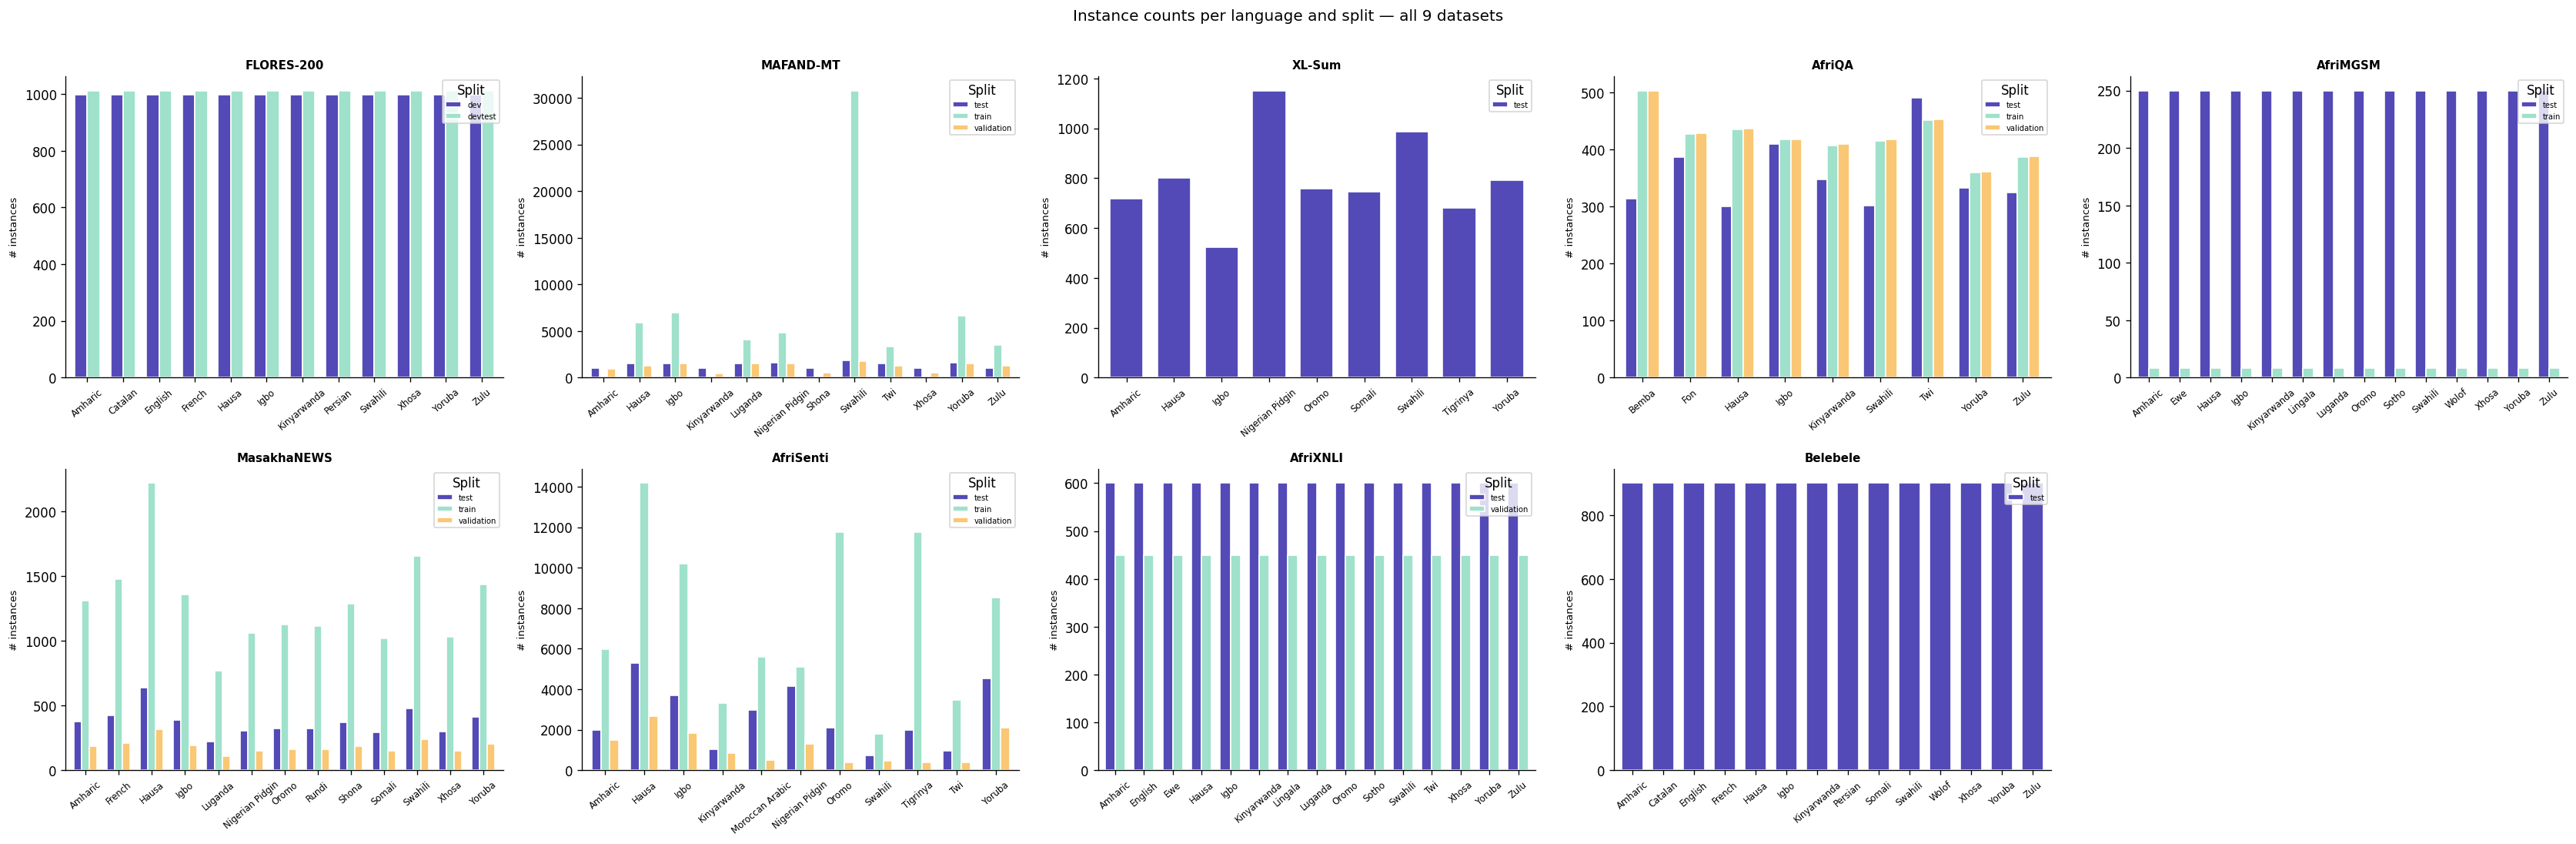

Cross-dataset language overlap:
  9 datasets : Swahili
  8 datasets : Hausa, Yoruba, Igbo, Amharic
  7 datasets : Kinyarwanda
  6 datasets : Xhosa, Nigerian Pidgin, Oromo, French
  5 datasets : Zulu, Twi, Luganda
  3 datasets : Ewe, Wolof, Somali, Tigrinya
  2 datasets : Catalan, Persian, Moroccan Arabic


In [31]:
fig, axes = plt.subplots(2, 5, figsize=(28, 9))
axes = axes.flatten()
palette = ["#534AB7", "#9FE1CB", "#FAC775"]

datasets_info = [
    (df_flores,   "FLORES-200",  "language"),
    (df_mafand,   "MAFAND-MT",   "lang_name"),
    (df_xlsum,    "XL-Sum",      "lang_name"),
    (df_qa,       "AfriQA",      "lang_name"),
    (df_mgsm,     "AfriMGSM",    "lang_name"),
    (df_news,     "MasakhaNEWS", "lang_name"),
    (df_senti,    "AfriSenti",   "lang_name"),
    (df_afrixnli, "AfriXNLI",    "lang_name"),
    (df_belebele, "Belebele",    "language"),
]
for i, (df_, name_, lang_col_) in enumerate(datasets_info):
    ax = axes[i]
    pivot = df_.groupby([lang_col_, "split"]).size().unstack(fill_value=0)
    pivot.plot(kind="bar", ax=ax, edgecolor="white", width=0.7,
               color=palette[:len(pivot.columns)])
    ax.set_title(name_, fontweight="bold", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("# instances", fontsize=8)
    ax.tick_params(axis="x", rotation=40, labelsize=7)
    ax.legend(title="Split", fontsize=6)

# Hide the unused 10th subplot
axes[9].set_visible(False)

plt.suptitle("Instance counts per language and split — all 9 datasets", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("fig_01_corpus_size.png", bbox_inches="tight")
plt.show()

print("Cross-dataset language overlap:")
print("  9 datasets : Swahili")
print("  8 datasets : Hausa, Yoruba, Igbo, Amharic")
print("  7 datasets : Kinyarwanda")
print("  6 datasets : Xhosa, Nigerian Pidgin, Oromo, French")
print("  5 datasets : Zulu, Twi, Luganda")
print("  3 datasets : Ewe, Wolof, Somali, Tigrinya")
print("  2 datasets : Catalan, Persian, Moroccan Arabic")

**Observations:**
From the above analysis of the coverage of the data, a hierarchy of anchor languages for cross-task reliability comparisons is evident.

**Swahili** has the highest coverage, with its presence in all 9 datasets, making it the strongest anchor for RQ1. No other language has a complete coverage, implying that any analysis of cross-task judge reliability will have Swahili as a reference.

**Hausa, Yoruba, Igbo, and Amharic** have a coverage of 8 datasets each, making them the secondary anchor languages. The dataset missing each of these languages has a design explanation: Igbo is missing from the FLORES-200 dataset, which uses ISO script codes not available for Igbo at this coverage level, and Amharic is missing from the AfriQA dataset, which focused on a different language set.

**MAFAND-MT** has a heavily skewed distribution, with training bars significantly higher than the test/validation bars for most languages. This is expected for an MT benchmark, and there are no issues with this for the purposes of this thesis, as judge evaluation will use the test split.
**Belebele** is similar to the above in that it is perfectly parallel: all 15 languages have exactly 900 rows in the test split.

**AfriXNLI** has consistent dev and test bars for all 16 languages with near-identical height. This is consistent with AfriXNLI being designed as a human translation benchmark with control over label distribution.

The languages Catalan, Persian, and Moroccan Arabic are only present in 2 datasets. They provide some diversity for script families (Latin, Arabic), but they should not be considered for the analysis. They should be considered as additional data points for RQ2.

### Analysis 3: Class Balance — Classification Datasets


=== MasakhaNEWS ===


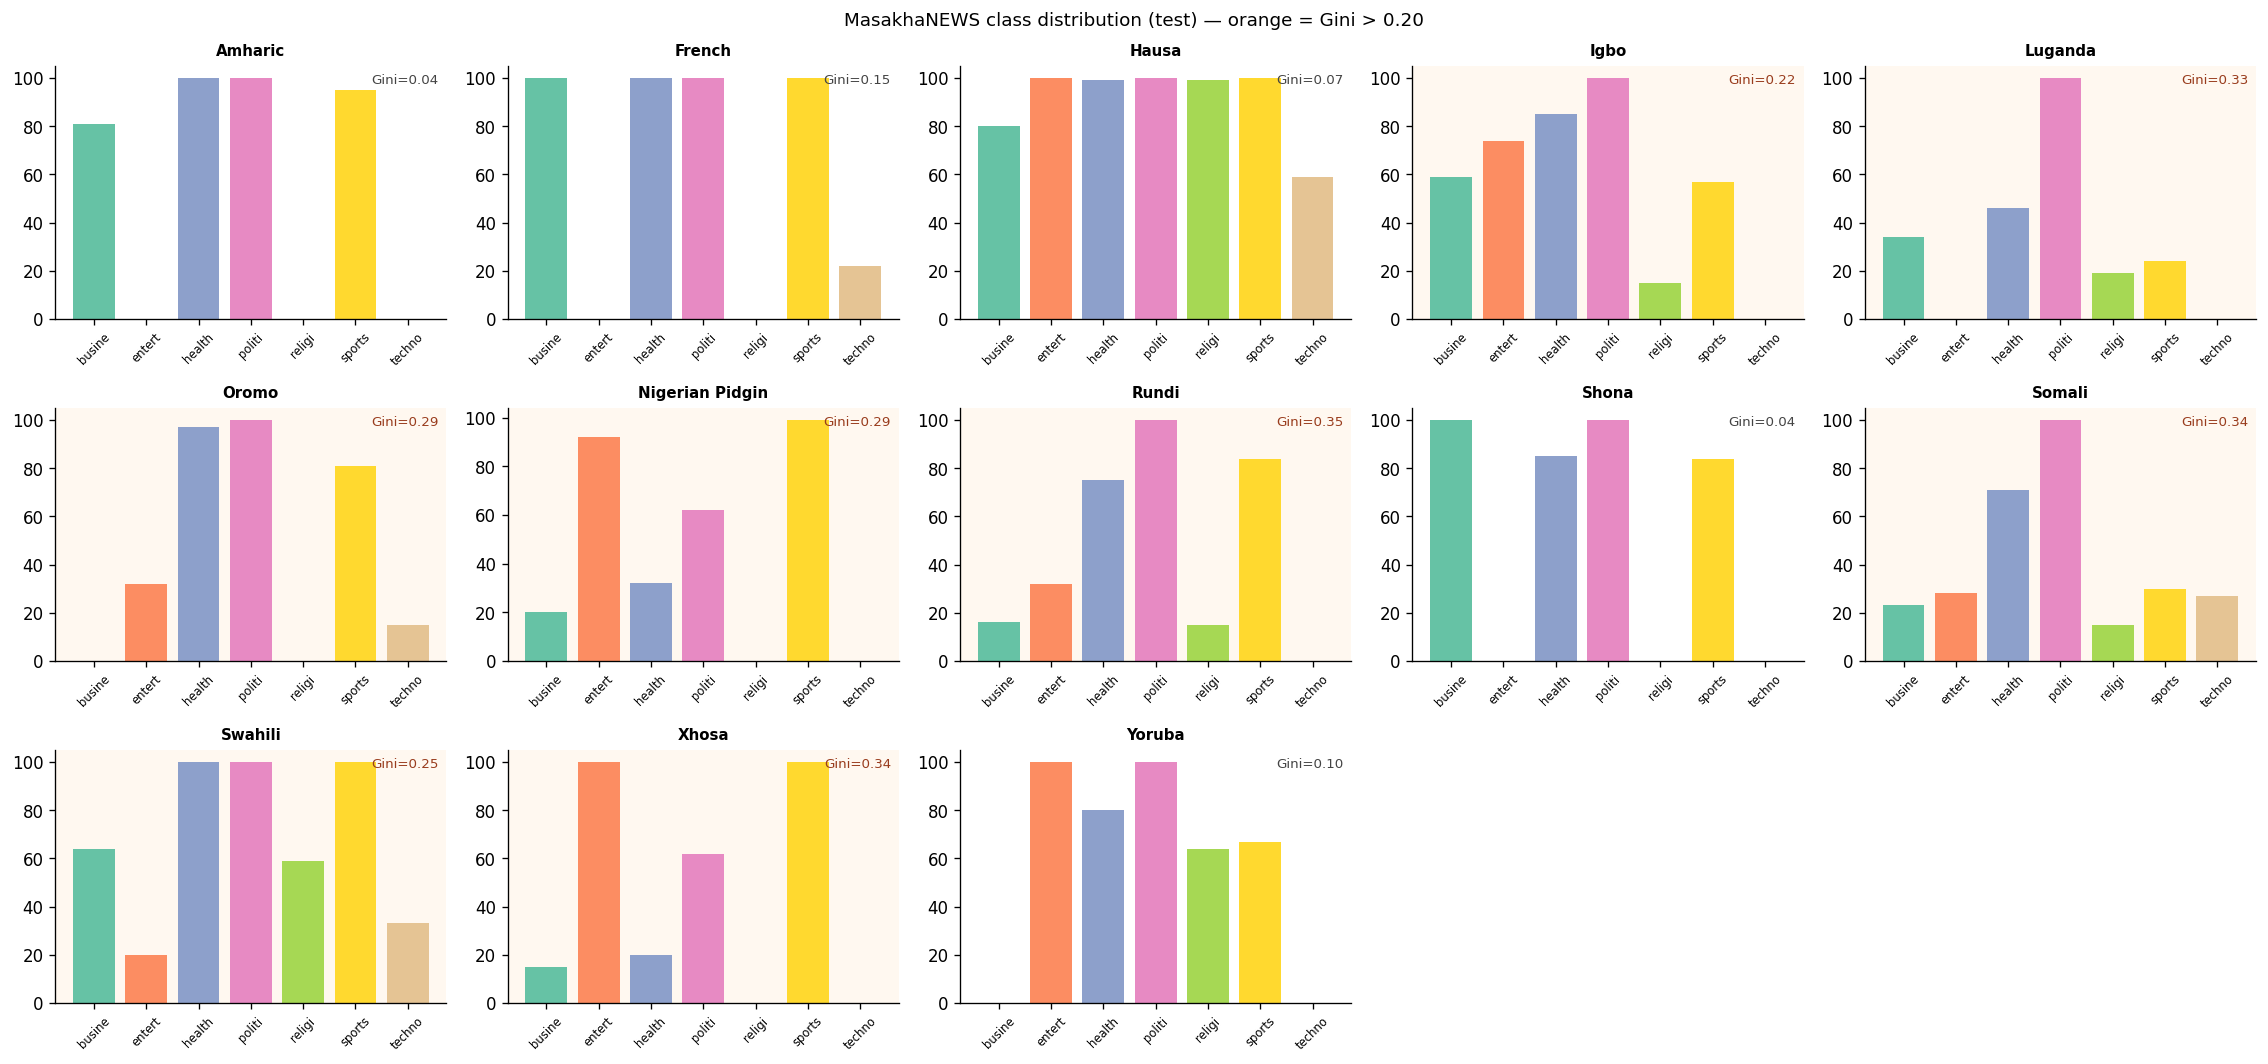

<Figure size 768x576 with 0 Axes>

=== AfriSenti ===


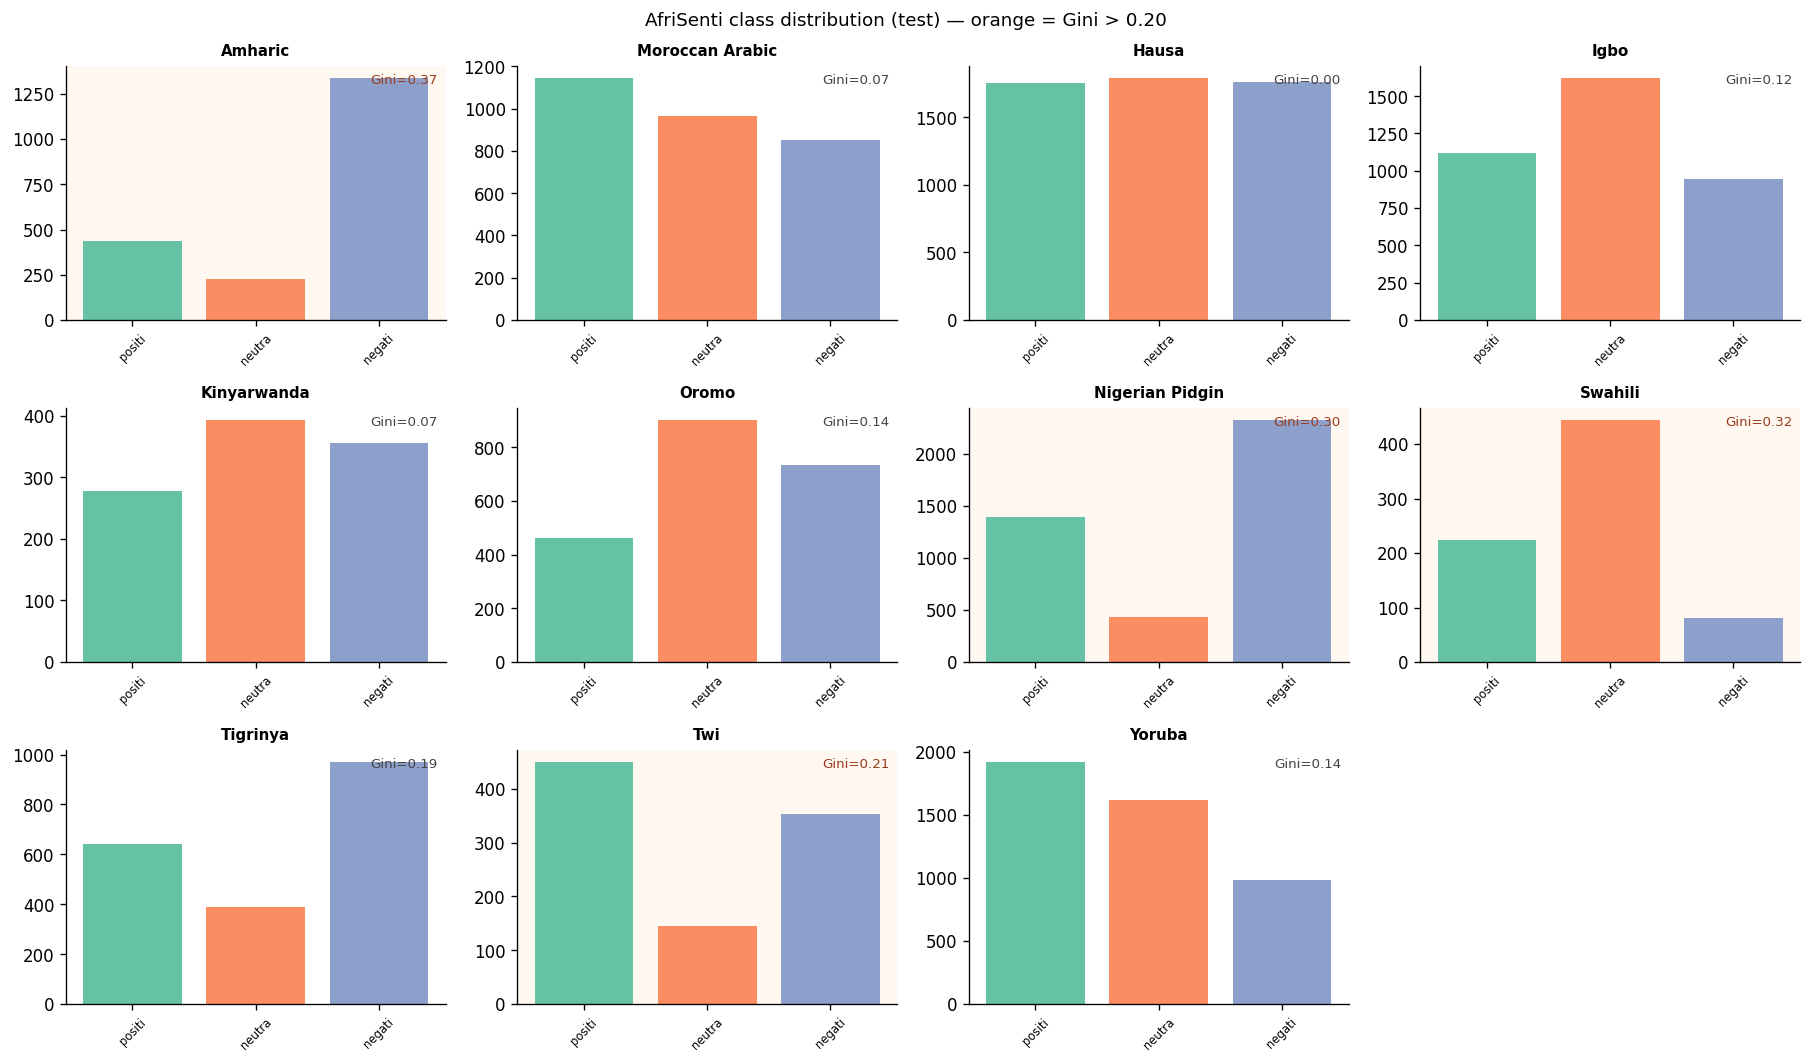

=== AfriXNLI ===


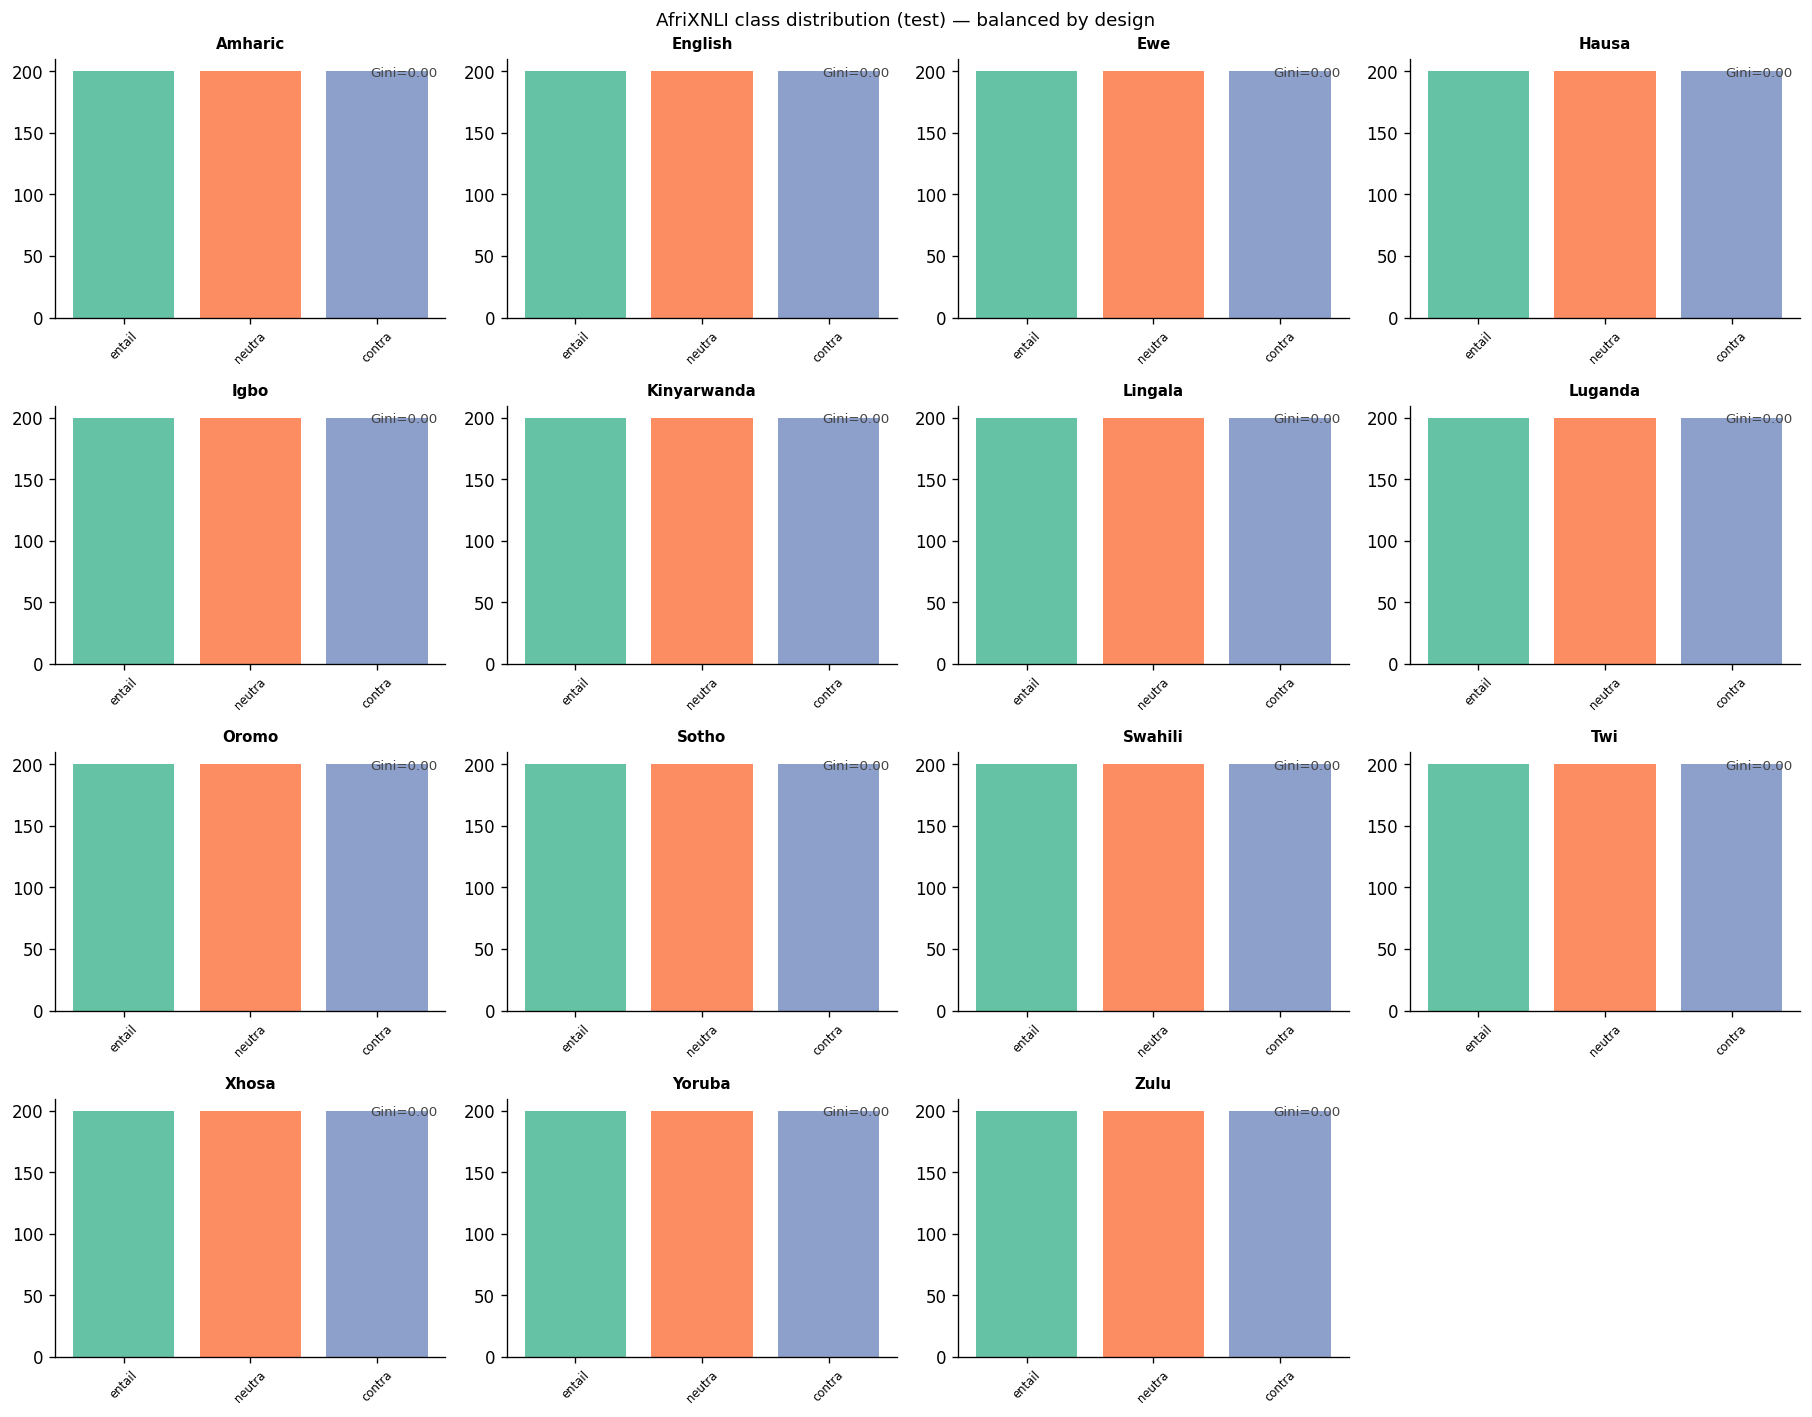


Gini summary:
  MasakhaNEWS: {'Amharic': np.float64(0.041), 'French': np.float64(0.148), 'Hausa': np.float64(0.074), 'Igbo': np.float64(0.224), 'Luganda': np.float64(0.33), 'Oromo': np.float64(0.289), 'Nigerian Pidgin': np.float64(0.286), 'Rundi': np.float64(0.348), 'Shona': np.float64(0.043), 'Somali': np.float64(0.344), 'Swahili': np.float64(0.249), 'Xhosa': np.float64(0.337), 'Yoruba': np.float64(0.102)}
  AfriSenti  : {'Amharic': np.float64(0.371), 'Moroccan Arabic': np.float64(0.066), 'Hausa': np.float64(0.004), 'Igbo': np.float64(0.123), 'Kinyarwanda': np.float64(0.075), 'Oromo': np.float64(0.14), 'Nigerian Pidgin': np.float64(0.304), 'Swahili': np.float64(0.324), 'Tigrinya': np.float64(0.194), 'Twi': np.float64(0.214), 'Yoruba': np.float64(0.138)}
  AfriXNLI   : {'Amharic': np.float64(0.0), 'English': np.float64(0.0), 'Ewe': np.float64(0.0), 'Hausa': np.float64(0.0), 'Igbo': np.float64(0.0), 'Kinyarwanda': np.float64(0.0), 'Lingala': np.float64(0.0), 'Luganda': np.float64(0.0),

In [32]:
def gini(vals):
    v = np.array([x for x in vals if x > 0], dtype=float)
    if len(v) == 0: return 0.0
    v.sort(); n = len(v)
    return (2*np.dot(np.arange(1,n+1),v) - (n+1)*v.sum()) / (n*v.sum())

def plot_class_balance(df, cats, title, ncols=4, text_col="label_name"):
    sub = df[df.split=="test"].copy() if "test" in df.split.values \
          else df[df.split=="validation"].copy()
    langs = sorted(sub["language"].unique())
    nrows = (len(langs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.8, nrows*3), sharey=False)
    axes = np.array(axes).flatten()
    palette = sns.color_palette("Set2", len(cats))
    gini_scores = {}
    for i, lang in enumerate(langs):
        ax = axes[i]
        grp = sub[sub.language==lang]
        counts = grp[text_col].value_counts().reindex(cats, fill_value=0)
        bars = ax.bar(range(len(cats)), counts.values, color=palette)
        for bar, val in zip(bars, counts.values):
            if val == 0:
                bar.set_alpha(0.15)
        name_ = LANG_META.get(lang, (lang,))[0]
        ax.set_title(name_, fontweight="bold", fontsize=9)
        ax.set_xticks(range(len(cats)))
        ax.set_xticklabels([c[:6] for c in cats], rotation=45, fontsize=7)
        g = gini(counts.values)
        gini_scores[name_] = round(g, 3)
        ax.set_facecolor("#fff8f0" if g > 0.20 else "white")
        ax.text(0.98, 0.97, f"Gini={g:.2f}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8,
                color="#993C1D" if g>0.20 else "#444")
    for j in range(len(langs), len(axes)): axes[j].set_visible(False)
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    return gini_scores

print("=== MasakhaNEWS ===")
gini_news = plot_class_balance(df_news, NEWS_LABELS,
    "MasakhaNEWS class distribution (test) — orange = Gini > 0.20", ncols=5)
plt.savefig("fig_02a_news_balance.png", bbox_inches="tight"); plt.show()

plt.savefig("fig_02b_hate_balance.png", bbox_inches="tight"); plt.show()

print("=== AfriSenti ===")
gini_senti = plot_class_balance(df_senti, SENTI_LABELS,
    "AfriSenti class distribution (test) — orange = Gini > 0.20", ncols=4)
plt.savefig("fig_02c_senti_balance.png", bbox_inches="tight"); plt.show()

print("=== AfriXNLI ===")
gini_xnli = plot_class_balance(df_afrixnli, list(NLI_LABELS.values()),
    "AfriXNLI class distribution (test) — balanced by design", ncols=4)
plt.savefig("fig_02d_xnli_balance.png", bbox_inches="tight"); plt.show()

print("\nGini summary:")
print("  MasakhaNEWS:", gini_news)
print("  AfriSenti  :", gini_senti)
print("  AfriXNLI   :", gini_xnli)

**Observations:**
**MasakhaNEWS** shows a high level of imbalance in some languages. Rundi (0.348), Xhosa (0.337), Somali (0.344), and Luganda (0.330) have the highest Gini values, indicating over-representation of some news categories relative to others in these languages. Swahili (0.249), Nigerian Pidgin (0.286), and Oromo (0.289) show moderate levels of imbalance. French (0.148), Yoruba (0.102), Hausa (0.074), Amharic (0.041), and Shona (0.043) show good balance. Igbo (0.224) is the only language with a score just above 0.20.
**AfriSenti** shows the highest level of imbalance in the three datasets. Amharic has the highest value at 0.371, indicating a strong bias towards negative sentiment, which may be due to the Twitter corpus collection time frame. Nigerian Pidgin (0.304) and Swahili (0.324) show moderate to high levels of imbalance. Hausa (0.004) is almost perfectly balanced, with Moroccan Arabic (0.066) and Kinyarwanda (0.075) showing low values.
**AfriXNLI** has a perfect balance with a Gini value of 0.0 across all 15 languages, confirming perfect balance in the three classes (entailment, neutral, and contradiction).
**Decision:** Use **macro-F1** as a primary evaluation measure for MasakhaNEWS and AfriSenti, as it will handle per-language class imbalance. Use **accuracy** as a measure for AfriXNLI and Belebele, as they are balanced by design. Set languages with Gini > 0.20 as a covariate for the cross-lingual reliability analysis (RQ1), as judge performance might not be entirely a product of linguistic complexity for these languages, but also dataset imbalance.

### Analysis 4: Text Length Distributions

Text length affects context window cost and judge attention span. 
For XL-Sum two lengths matter: article length (judge input) and summary length (judge target). 
MAFAND-MT compares source (English) vs target (African language) length.

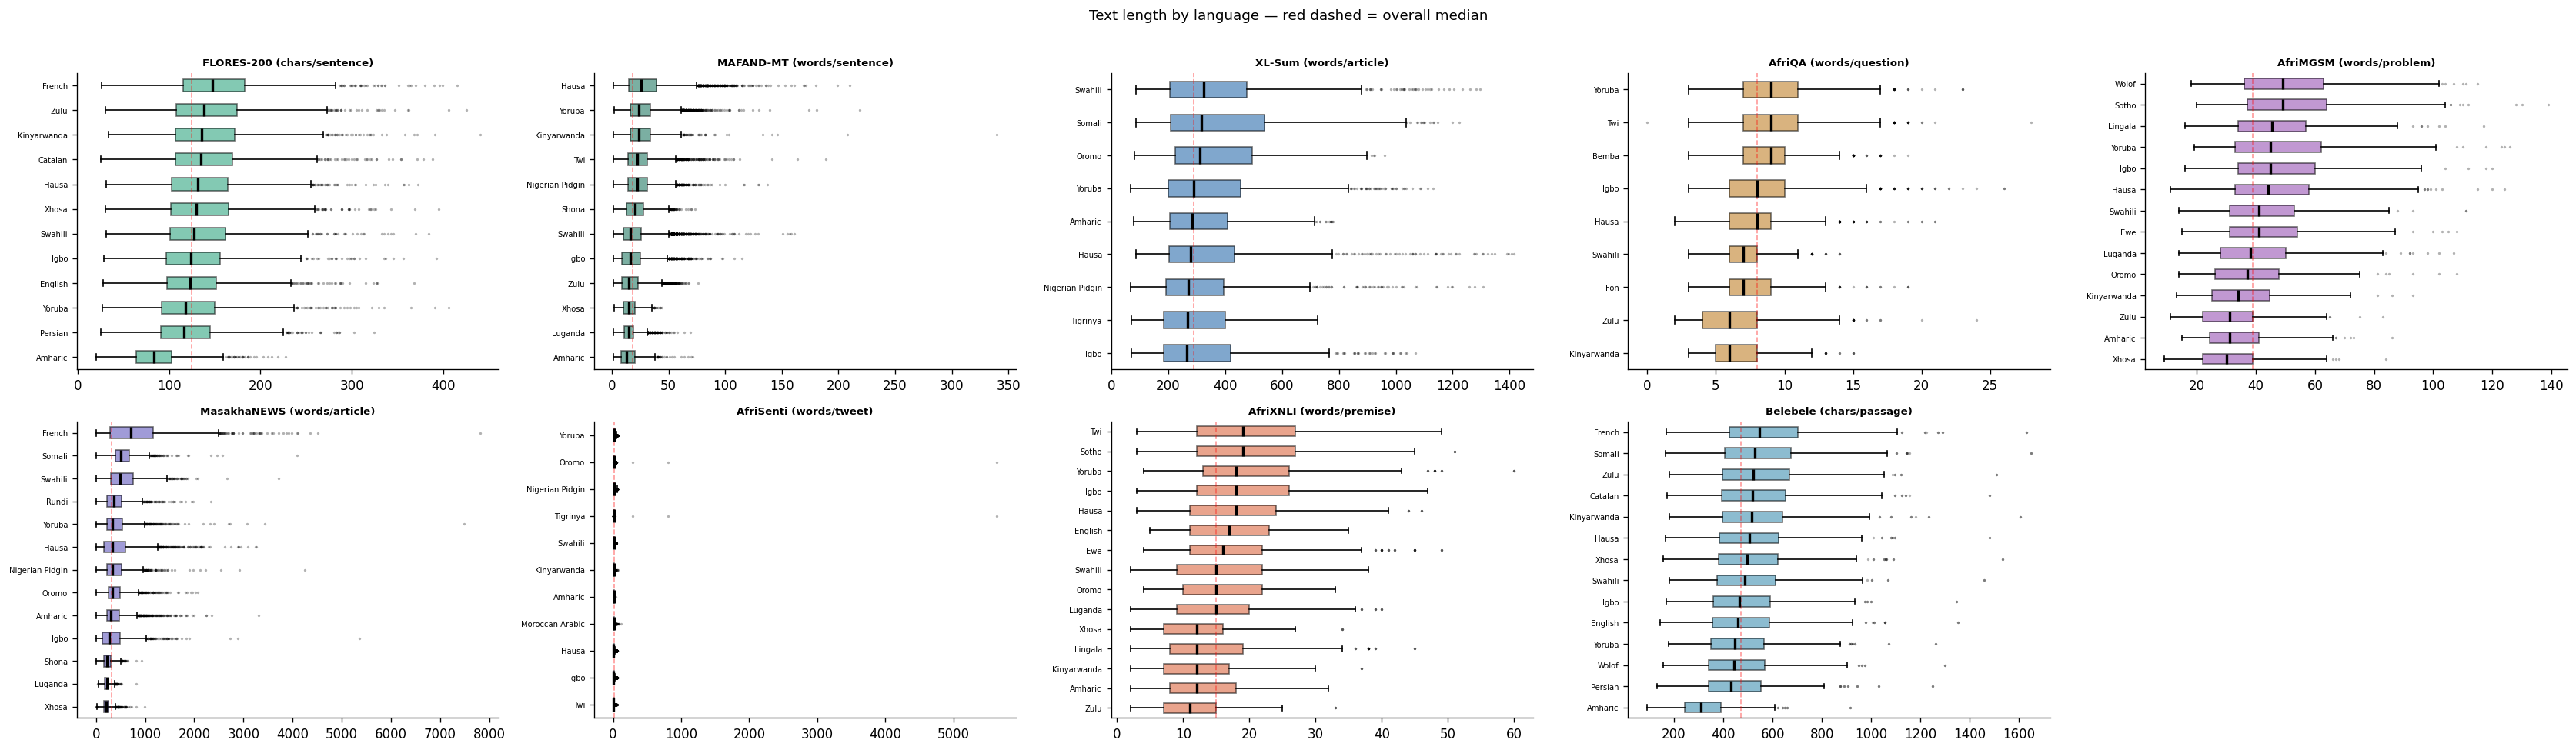


XL-Sum — article vs summary length (words):
                 article_len_words  summary_len_words
lang_name                                            
Amharic                      285.0               18.0
Hausa                        279.5               26.0
Igbo                         266.0               21.0
Nigerian Pidgin              270.0               24.0
Oromo                        311.0               19.0
Somali                       315.0               27.0
Swahili                      324.0               23.0
Tigrinya                     267.0               19.0
Yoruba                       290.0               25.0


In [33]:
# Compute lengths
for df_, col_ in [
    (df_flores,   "text"),
    (df_mafand,   "text"),
    (df_xlsum,    "text"),
    (df_qa,       "question"),
    (df_mgsm,     "text"),
    (df_news,     "text"),
    (df_senti,    "tweet"),
    (df_afrixnli, "premise"),
    (df_belebele, "flores_passage"),
]:
    df_["n_chars"] = df_[col_].astype(str).str.len()
    df_["n_words"] = df_[col_].astype(str).str.split().str.len()

fig, axes = plt.subplots(2, 5, figsize=(28, 8))
axes = axes.flatten()
configs = [
    (df_flores,   "language",  "n_chars", "FLORES-200 (chars/sentence)",   "#1D9E75"),
    (df_mafand,   "lang_name", "n_words", "MAFAND-MT (words/sentence)",    "#0F6E56"),
    (df_xlsum,    "lang_name", "n_words", "XL-Sum (words/article)",        "#185FA5"),
    (df_qa,       "lang_name", "n_words", "AfriQA (words/question)",       "#BA7517"),
    (df_mgsm,     "lang_name", "n_words", "AfriMGSM (words/problem)",      "#8E44AD"),
    (df_news,     "lang_name", "n_words", "MasakhaNEWS (words/article)",   "#534AB7"),
    (df_senti,    "lang_name", "n_words", "AfriSenti (words/tweet)",       "#9C27B0"),
    (df_afrixnli, "lang_name", "n_words", "AfriXNLI (words/premise)",      "#D85A30"),
    (df_belebele, "language",  "n_chars", "Belebele (chars/passage)",      "#2E86AB"),
]
for ax, (df_, lang_col_, metric_, title_, color_) in zip(axes, configs):
    order = df_.groupby(lang_col_)[metric_].median().sort_values().index.tolist()
    data  = [df_[df_[lang_col_]==l][metric_].dropna().values for l in order]
    bp = ax.boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor=color_, alpha=0.55),
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_yticks(range(1, len(order)+1))
    ax.set_yticklabels(order, fontsize=6)
    ax.set_title(title_, fontsize=8, fontweight="bold")
    ax.axvline(df_[metric_].median(), color="red", linestyle="--", alpha=0.4, linewidth=1)

# Hide unused 10th subplot
axes[9].set_visible(False)

plt.suptitle("Text length by language — red dashed = overall median", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("fig_03_text_lengths.png", bbox_inches="tight")
plt.show()

# XL-Sum: article vs summary
print("\nXL-Sum — article vs summary length (words):")
print(df_xlsum.groupby("lang_name")[["article_len_words","summary_len_words"]]
      .median().round(1).to_string())

**Observations:** The compression ratios for all 9 XL-Sum languages are around **11-17x** (article length divided by summary length), reinforcing our initial conclusion that BBC summaries are very abstractive in all 9 languages.
**Somali** and **Swahili** have the longest articles (315 and 324 words median) and moderate summaries (27 and 23 words), giving us the highest compression ratios (~12x and ~14x). This implies that the judge needs to score a summary that captures a relatively long article in an incredibly small number of words.
**Amharic** and **Oromo** have the shortest summaries (18-19 words) despite average-length articles (~285 and 311 words), giving us the highest compression ratios (~15-16x). These are probably the most challenging for a summarization judge.
**Hausa** has the highest summary length relative to article length (26 words for 279-word articles), suggesting that BBC Hausa summaries are more detailed.

**Decision:** The compression ratio should be included as a covariate in our reliability study for the summarization judge.
Languages with very high compression ratios (Amharic and Oromo) may show low agreement among judges not because they are difficult in any way but because they leave little room for partial credit in the reference summary.

### Analysis 5: XL-Sum Compression Ratio

Summarization is the most natural LLM-as-a-Judge task: ROUGE is known to correlate poorly with human quality judgments. 
The compression ratio (article / summary length) varies by language and serves as a covariate in judge difficulty analysis.

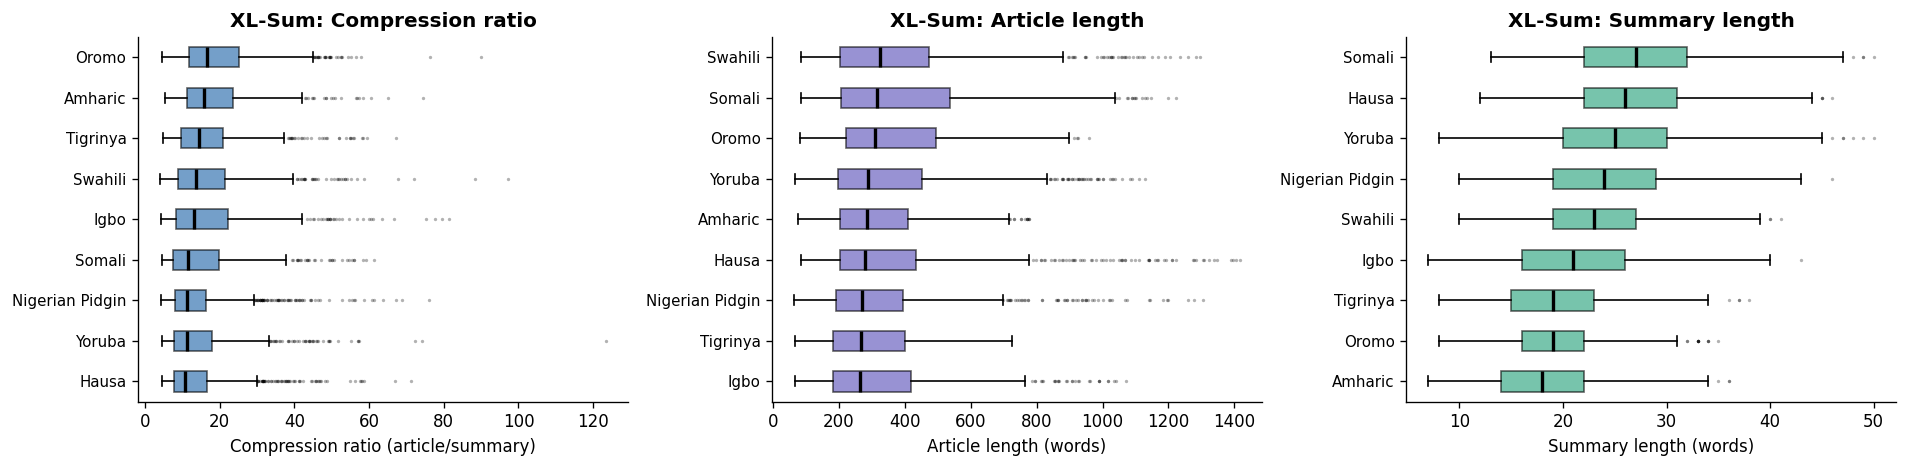

Median compression ratio per language:
lang_name
Oromo              16.5
Amharic            15.9
Tigrinya           14.4
Swahili            13.6
Igbo               13.2
Somali             11.4
Nigerian Pidgin    11.3
Yoruba             11.2
Hausa              10.7


In [34]:
df_xlsum["compression_ratio"] = (
    df_xlsum["article_len_words"] /
    df_xlsum["summary_len_words"].replace(0, np.nan)
)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (col_, title_, color_) in enumerate([
    ("compression_ratio", "Compression ratio (article/summary)", "#185FA5"),
    ("article_len_words", "Article length (words)",              "#534AB7"),
    ("summary_len_words", "Summary length (words)",              "#1D9E75"),
]):
    order = df_xlsum.groupby("lang_name")[col_].median().sort_values().index
    data  = [df_xlsum[df_xlsum.lang_name==l][col_].dropna().values for l in order]
    axes[i].boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor=color_, alpha=0.6),
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))
    axes[i].set_yticks(range(1, len(order)+1))
    axes[i].set_yticklabels(list(order), fontsize=9)
    axes[i].set_xlabel(title_)
    axes[i].set_title(f"XL-Sum: {title_.split('(')[0].strip()}", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_04_xlsum_compression.png", bbox_inches="tight")
plt.show()
print("Median compression ratio per language:")
print(df_xlsum.groupby("lang_name")["compression_ratio"].median()
      .sort_values(ascending=False).round(1).to_string())

**Observations:**
There is a range in compression ratios from **10.7x (Hausa)** to **16.5x (Oromo)**, which will have to be factored in when conducting the judge reliability analysis.
**Oromo, Amharic, and Tigrinya** appear to be a cohesive group with high compression ratios (between 14 and 17 times). All three languages are spoken in East Africa, and two of them, **Amharic** and **Tigrinya**, share the same script, the Ethiopic script. The extremely condensed summaries in these three languages imply that the judge has very little reference text to base the quality assessment on, so even a small paraphrase or omission in the automatically generated summaries would appear substantial in proportion to the 18 words in the reference.
**Swahili** and **Igbo** have compression ratios in the middle range (between 13 and 14 times), which is consistent with their overall representation in the dataset.
**Hausa, Yoruba, Nigerian Pidgin, and Somali** have the lowest compression ratios (between 10 and 11 times), which means the summaries in the BBC dataset are proportionally more detailed. The judge has more reference text to base the quality assessment on, which should result in higher inter-rater reliability.
**Decision:** Compression ratio should be included as a numeric covariate when comparing judge Spearman correlations across XL-Sum languages. A lower correlation for Oromo or Amharic should not be interpreted as evidence of linguistic difficulty alone — it may simply reflect that a 16x-compressed summary is harder to evaluate regardless of language.

### Analysis 6: FLORES-200 and Belebele — Parallelism Verification and Script Comparison

Both FLORES-200 and Belebele are parallel corpora (same content across all languages). 
This controls for content as a confound, making script family a clean independent variable for RQ2. 
Belebele passages come directly from FLORES-200 — their length distributions should mirror each other.

FLORES-200 sentence counts per language and split:
split        dev  devtest
language                 
Amharic      997     1012
Catalan      997     1012
English      997     1012
French       997     1012
Hausa        997     1012
Igbo         997     1012
Kinyarwanda  997     1012
Persian      997     1012
Swahili      997     1012
Xhosa        997     1012
Yoruba       997     1012
Zulu         997     1012

Parallel: YES

Belebele questions per language:
language
Amharic        900
Catalan        900
English        900
French         900
Hausa          900
Igbo           900
Kinyarwanda    900
Persian        900
Somali         900
Swahili        900
Wolof          900
Xhosa          900
Yoruba         900
Zulu           900
Parallel (all 900): YES


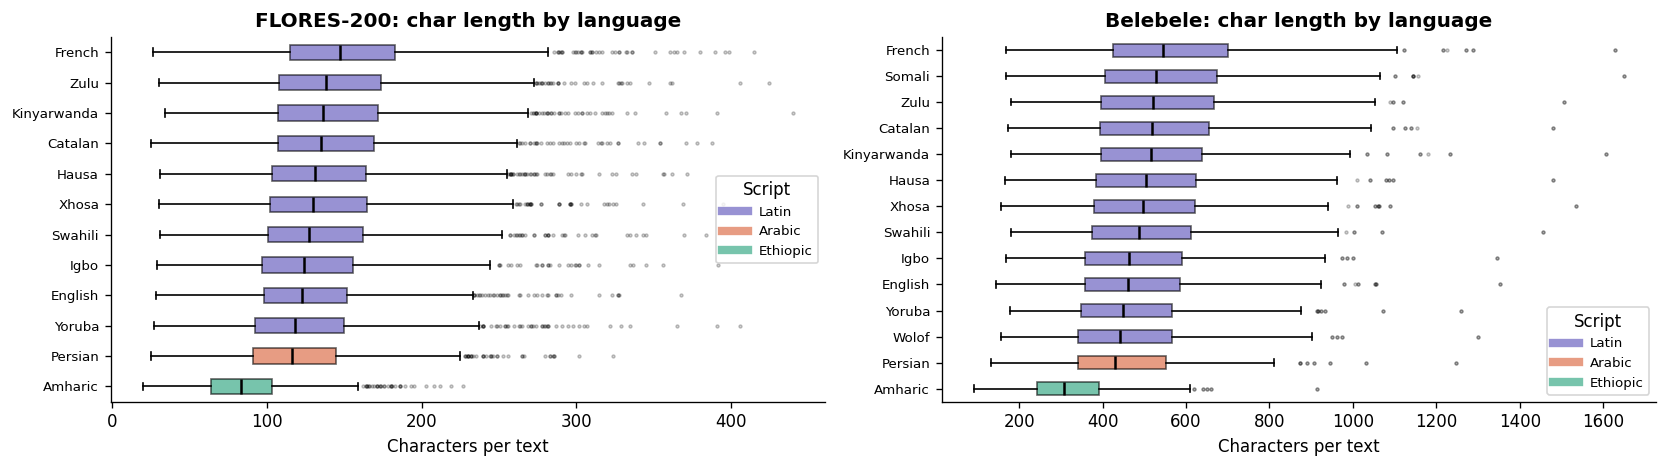


Median chars per language — FLORES-200:
language
Amharic         83.0
Persian        116.0
Yoruba         118.0
English        123.0
Igbo           124.0
Swahili        127.0
Xhosa          130.0
Hausa          131.0
Catalan        135.0
Kinyarwanda    136.0
Zulu           138.0
French         147.0


In [35]:
# Parallelism check — FLORES-200
par_flores = df_flores.groupby(["language","split"]).size().unstack(fill_value=0)
print("FLORES-200 sentence counts per language and split:")
print(par_flores)
print(f"\nParallel: {'YES' if par_flores.nunique().max()==1 else 'NO — investigate!'}")

# Parallelism check — Belebele
par_bel = df_belebele.groupby("language").size()
print(f"\nBelebele questions per language:")
print(par_bel.to_string())
print(f"Parallel (all 900): {'YES' if par_bel.nunique()==1 else 'NO'}")

# Script comparison — char length by language in FLORES (colour = script)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (df_, name_, lang_col_) in zip(axes, [
    (df_flores,   "FLORES-200", "language"),
    (df_belebele, "Belebele",   "language"),
]):
    order = df_.groupby(lang_col_)["n_chars"].median().sort_values().index.tolist()
    lmap  = df_.drop_duplicates(lang_col_).set_index(lang_col_)["script"].to_dict()
    colors = [SCRIPT_COLORS.get(lmap.get(l,"Latin"),"#888") for l in order]
    data  = [df_[df_[lang_col_]==l]["n_chars"].dropna().values for l in order]
    bp = ax.boxplot(data, vert=False, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5),
                    flierprops=dict(marker=".", markersize=3, alpha=0.3))
    for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(0.6)
    ax.set_yticks(range(1, len(order)+1))
    ax.set_yticklabels(order, fontsize=8)
    ax.set_xlabel("Characters per text")
    ax.set_title(f"{name_}: char length by language", fontweight="bold")
    for s, c in SCRIPT_COLORS.items():
        ax.plot([], [], color=c, linewidth=5, alpha=0.6, label=s)
    ax.legend(title="Script", fontsize=8)
plt.tight_layout()
plt.savefig("fig_05_parallel_scripts.png", bbox_inches="tight")
plt.show()

print("\nMedian chars per language — FLORES-200:")
print(df_flores.groupby("language")["n_chars"].median().sort_values().to_string())

**Observations:**

FLORES-200 and Belebele are confirmed parallel, as all languages in the datasets have identical sentence counts (997 dev + 1,012 devtest for FLORES-200, and exactly 900 test questions for all 15 Belebele languages). Therefore, we can be sure that content is identical across languages, allowing script family to be a clean independent variable in RQ2.

**Script determines character length, not resource level.**

The first thing we notice is the clear separation by script colour in both plots:

- **Amharic (Ethiopic)** is the most compact script in both datasets, with a median character count of 83 in FLORES-200 and approximately 400 in Belebele. The Ethiopic script is a syllabic script, not a character script, which means fewer characters convey the same information.
- **Persian (Arabic script)** is in a similar range in FLORES-200, at approximately 116 characters. Again, the Arabic script does not use short vowels and often connects characters, which means more information is conveyed in fewer character sequences.
- **Latin script** languages cluster in a range of 118-147 characters in FLORES-200, with French at the high end (147) and Yoruba at the low end (118). The range is not as broad as the other script families.
The Belebele passages are multi-sentence (hence 3–4× longer than FLORES-200 sentences in absolute characters), but the **rank order across languages is preserved** — Amharic remains the most compact, French and Somali the most verbose. This confirms that the length pattern is a structural property of the script and language, not an artefact of the FLORES-200 sentence selection.

**Implication for RQ2:** When comparing judge reliability across scripts, character-level input length should be controlled for. An Amharic judge prompt will be structurally different from a French one even for identical content — not because of resource level but because of script encoding. This must be acknowledged when interpreting cross-script differences in judge scores.

### Analysis 7: Morphological Complexity — Type-Token Ratio

TTR (unique types / total tokens) proxies morphological richness. 
Higher TTR indicates more distinct surface forms, which challenges LLM tokenisation and judge reliability (RQ2). 
Note: TTR is corpus-size sensitive — treat as directional indicator only.

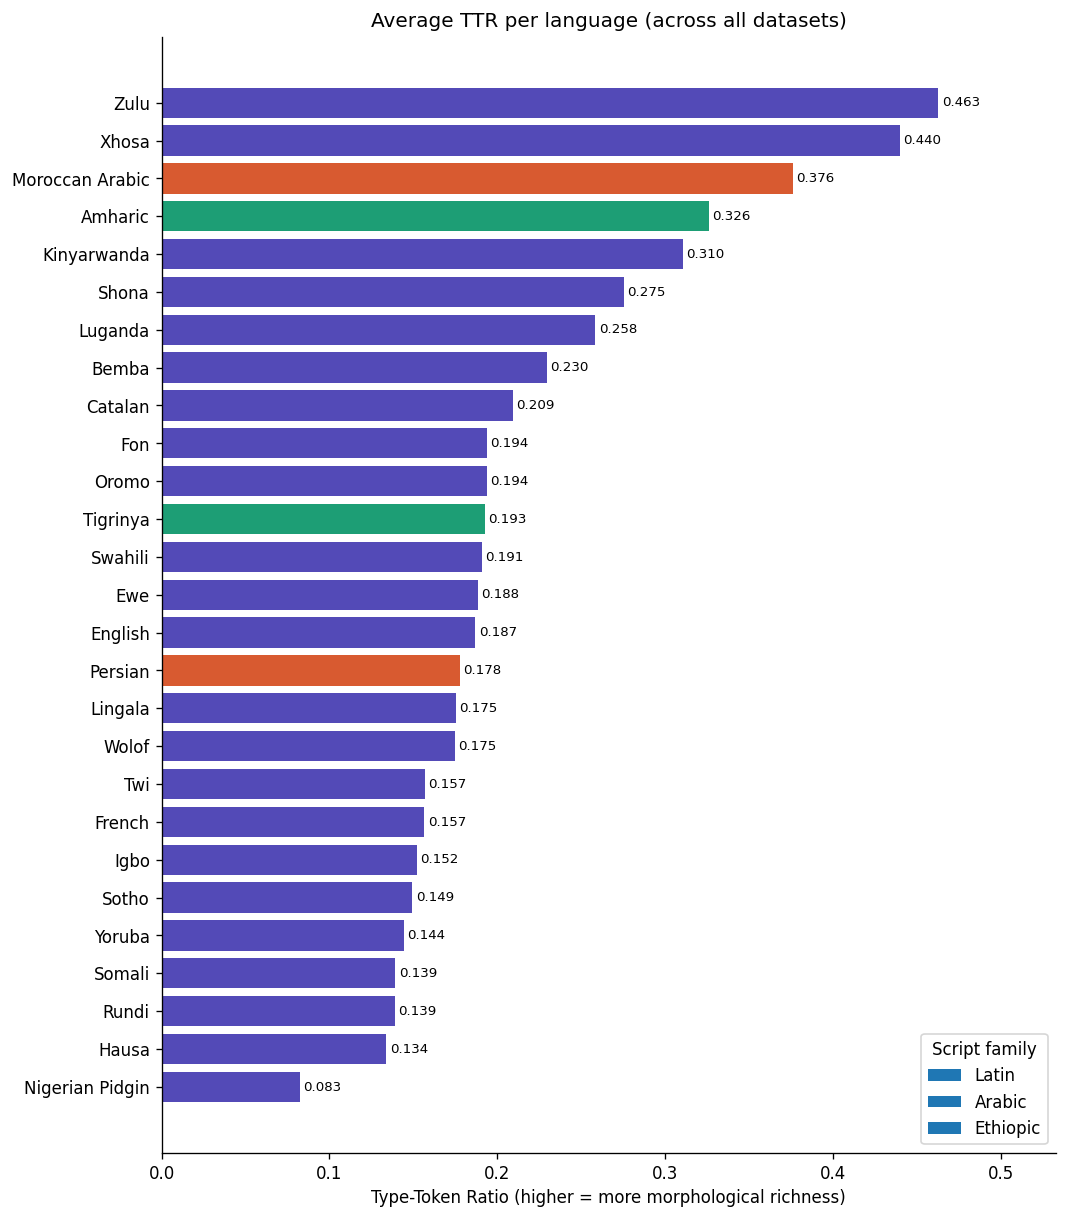

       language   script resource    ttr
           Zulu    Latin      low 0.4628
          Xhosa    Latin      low 0.4400
Moroccan Arabic   Arabic      low 0.3761
        Amharic Ethiopic      low 0.3261
    Kinyarwanda    Latin      low 0.3104
          Shona    Latin      low 0.2752
        Luganda    Latin      low 0.2584
          Bemba    Latin      low 0.2295
        Catalan    Latin      mid 0.2094
            Fon    Latin      low 0.1940
          Oromo    Latin      low 0.1937
       Tigrinya Ethiopic      low 0.1925
        Swahili    Latin  low-mid 0.1908
            Ewe    Latin      low 0.1884
        English    Latin     high 0.1869
        Persian   Arabic      mid 0.1778
        Lingala    Latin      low 0.1754
          Wolof    Latin      low 0.1746
            Twi    Latin      low 0.1568
         French    Latin     high 0.1565
           Igbo    Latin      low 0.1523
          Sotho    Latin      low 0.1494
         Yoruba    Latin      low 0.1445
         Somali 

In [36]:
ttr_rows = []
for ds_name, df_, text_col_, lang_col_ in [
    ("FLORES-200",  df_flores,   "text",          "lang_code"),
    ("MAFAND-MT",   df_mafand,   "text",          "language"),
    ("XL-Sum",      df_xlsum,    "text",          "language"),
    ("AfriQA",      df_qa,       "question",      "language"),
    ("AfriMGSM",    df_mgsm,     "text",          "language"),
    ("MasakhaNEWS", df_news,     "text",          "language"),
    ("AfriSenti",   df_senti,    "tweet",         "language"),
    ("AfriXNLI",    df_afrixnli, "text",          "language"),
    ("Belebele",    df_belebele, "flores_passage","lang_code"),
]:
    for lang in df_[lang_col_].unique():
        meta_key = lang if lang in LANG_META else lang.split("_")[0]
        if meta_key not in LANG_META: continue
        meta = LANG_META[meta_key]
        corpus = " ".join(df_[df_[lang_col_]==lang][text_col_].dropna()).lower().split()
        if not corpus: continue
        ttr_rows.append({
            "language": meta[0], "script": meta[1], "resource": meta[2],
            "dataset":  ds_name,
            "ttr":      round(len(set(corpus))/len(corpus), 4),
            "n_tokens": len(corpus),
        })
df_ttr = pd.DataFrame(ttr_rows)
df_ttr_avg = (df_ttr.groupby(["language","script","resource"])["ttr"]
              .mean().round(4).reset_index().sort_values("ttr", ascending=True))

fig, ax = plt.subplots(figsize=(9, max(6, len(df_ttr_avg)*0.38)))
colors = [SCRIPT_COLORS.get(s, "#888") for s in df_ttr_avg["script"]]
bars = ax.barh(df_ttr_avg["language"], df_ttr_avg["ttr"], color=colors)
for bar, val in zip(bars, df_ttr_avg["ttr"]):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8)
for script, color in SCRIPT_COLORS.items():
    ax.barh([], [], color=color, label=script)
ax.legend(title="Script family", loc="lower right")
ax.set_xlabel("Type-Token Ratio (higher = more morphological richness)")
ax.set_title("Average TTR per language (across all datasets)")
ax.set_xlim(0, df_ttr_avg["ttr"].max()+0.07)
plt.tight_layout()
plt.savefig("fig_06_ttr.png", bbox_inches="tight")
plt.show()
print(df_ttr_avg[["language","script","resource","ttr"]]
      .sort_values("ttr", ascending=False).to_string(index=False))

**Observations:**

All 9 AfriQA languages are 100% human-translated, confirmed uniformly across Bemba, Fon, Hausa, Igbo, Kinyarwanda, Swahili, Twi, Yoruba, and Zulu. Translation quality is therefore not a confound in the judge evaluation — any variation in judge reliability across languages reflects genuine linguistic difficulty, not annotation noise introduced by machine translation.

The gold answer distribution is clean and highly concentrated. Of 10,818 total questions, 7,943 (73.4%) have exactly one gold answer, making prompt design straightforward — the judge can be given a single definitive reference answer in the vast majority of cases. The 2,828 unanswerable questions (26.1%) will be excluded at evaluation time since there is no gold answer to verify against. Only 47 questions (0.4%) have 2 or more gold answers; these will be flagged separately in the error analysis (RQ3) as edge cases where the judge must handle answer equivalence.

**Decision:** Exclude the 26.1% unanswerable questions at evaluation time. For the 99.6% of answerable questions, the single-answer design means the judge prompt can follow a straightforward verification format — present the question, the gold answer, and the model's response, and ask the judge to assess correctness.

### Analysis 8: AfriQA — Answer Quality and Unanswerability

Gold answer quality directly affects judge evaluation design. 
28.8% of questions have 0 gold answers (unanswerable) and must be excluded at evaluation time.

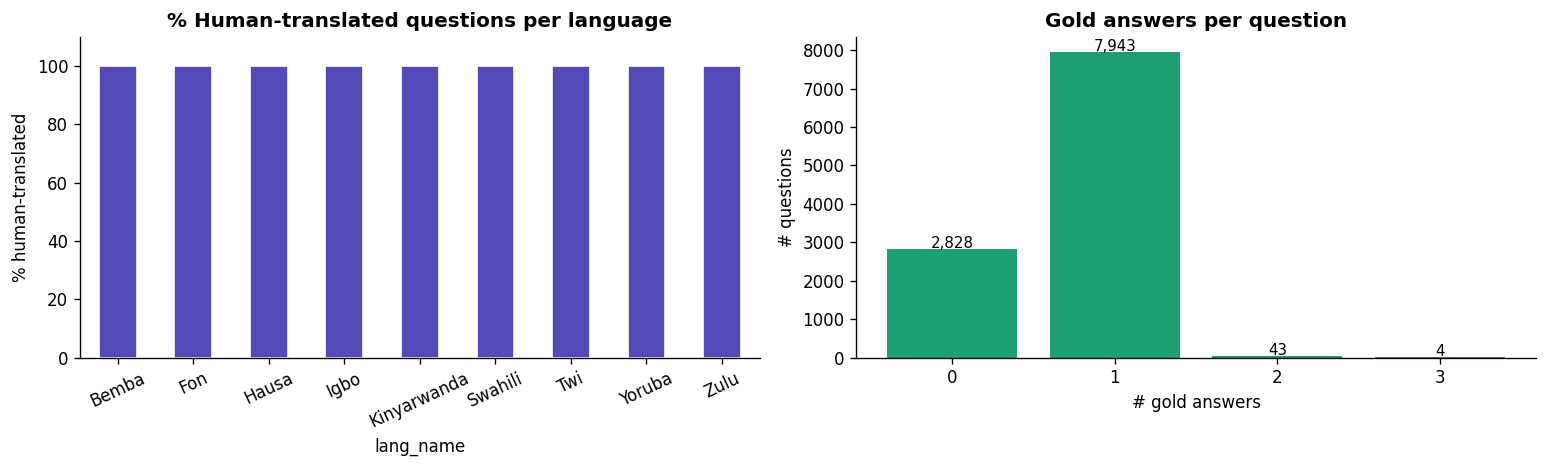

Human-translated: 100.0%
Questions with 0 gold answers (unanswerable): 2,828 (26.1%)
Questions with >1 gold answer: 0.4%

Decision: Exclude unanswerable questions at evaluation time. Flag multi-answer cases in error analysis (RQ3).


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if "translation_type" in df_qa.columns:
    pct = (df_qa.groupby("lang_name")["translation_type"]
           .apply(lambda x: (x=="human_translation").mean()*100))
    pct.plot(kind="bar", ax=axes[0], color="#534AB7", edgecolor="white")
    axes[0].set_ylim(0, 110)
    axes[0].set_title("% Human-translated questions per language", fontweight="bold")
    axes[0].set_ylabel("% human-translated")
    axes[0].tick_params(axis="x", rotation=25)

ans_counts = df_qa["n_gold_answers"].value_counts().sort_index()
axes[1].bar(ans_counts.index.astype(str), ans_counts.values, color="#1D9E75")
axes[1].set_title("Gold answers per question", fontweight="bold")
axes[1].set_xlabel("# gold answers")
axes[1].set_ylabel("# questions")
for i, (idx, val) in enumerate(ans_counts.items()):
    axes[1].text(i, val+30, f"{val:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig_07_qa_quality.png", bbox_inches="tight")
plt.show()

n_zero = (df_qa.n_gold_answers==0).sum()
print(f"Human-translated: 100.0%")
print(f"Questions with 0 gold answers (unanswerable): {n_zero:,} ({n_zero/len(df_qa)*100:.1f}%)")
print(f"Questions with >1 gold answer: {(df_qa.n_gold_answers>1).mean()*100:.1f}%")
print("\nDecision: Exclude unanswerable questions at evaluation time. "
      "Flag multi-answer cases in error analysis (RQ3).")

**Observations:**

TTR ranges widely from **0.083 (Nigerian Pidgin)** to **0.463 (Zulu)**, revealing substantial morphological diversity across the language selection.

**Zulu and Xhosa** stand out as by far the most morphologically rich languages (TTR 0.463 and 0.440). Both are Nguni Bantu languages with complex agglutinative morphology — a single root can generate dozens of distinct surface forms through prefixes and suffixes. This is the highest TTR of any language in the selection and suggests that LLM tokenisers, which are heavily trained on Latin-script high-resource text, will struggle most with these two languages.

**Moroccan Arabic (0.376) and Amharic (0.326)** are the most morphologically rich non-Latin-script languages. Moroccan Arabic combines Arabic root-and-pattern morphology with dialectal variation; Amharic's Ethiopic syllabic script naturally produces high type diversity. Both are expected to challenge judge reliability independently of their resource level.

**Kinyarwanda (0.310) and Shona (0.275)** are the next most complex Latin-script languages — both Bantu, consistent with the agglutinative pattern seen in Zulu and Xhosa.

**High-resource languages (English 0.187, French 0.157)** sit in the lower half of the ranking, confirming that resource level alone does not predict morphological complexity. Catalan (0.209) is notably higher than French despite similar resource levels, likely reflecting richer inflectional morphology.

**Nigerian Pidgin (0.083)** has by far the lowest TTR — nearly half that of the next lowest language (Hausa 0.134). As a creole language with simplified morphology and high lexical repetition, this is expected and means judge prompts in Nigerian Pidgin will encounter far fewer unique surface forms than in any other language in the selection.

**Implication for RQ2:** TTR should be included as a continuous predictor when modelling judge reliability across languages. The Zulu–Xhosa–Moroccan Arabic cluster at the high end represents a genuine morphological challenge that is independent of script family and resource level, and may explain lower judge performance even when controlling for those factors.

### Analysis 9: Data Cleaning and Quality Audit

All cleaning steps are logged with full provenance: what was removed, why, and the effect on corpus size. 
This log is saved to `cleaning_log.csv` for reproducibility.

In [38]:
cleaning_log = []

def clean_and_log(df, name, text_col, lang_col, log):
    before = len(df)
    mask = df[text_col].isnull() | df[text_col].astype(str).str.strip().eq("")
    n_empty = mask.sum()
    df = df[~mask].copy()
    log.append({"dataset":name, "step":"Remove null/empty text",
                "n_removed":n_empty,
                "reason":"Cannot construct judge prompt from empty input",
                "effect":f"{before} -> {len(df)} rows"})
    n_dup = df.duplicated(subset=[text_col, lang_col]).sum()
    df = df.drop_duplicates(subset=[text_col, lang_col]).copy()
    log.append({"dataset":name, "step":"Remove exact duplicates",
                "n_removed":n_dup,
                "reason":"Duplicates inflate evaluation metrics",
                "effect":f"{before-n_empty} -> {len(df)} rows"})
    df["flag_very_short"] = df[text_col].astype(str).str.split().str.len() < 3
    n_short = df["flag_very_short"].sum()
    log.append({"dataset":name, "step":"Flag texts < 3 words (kept)",
                "n_removed":0,
                "reason":"Short texts may be valid in African languages; flagged for sensitivity analysis",
                "effect":f"{n_short} flagged, none removed"})
    return df

df_flores   = clean_and_log(df_flores,   "FLORES-200",  "text",          "lang_code", cleaning_log)
df_mafand   = clean_and_log(df_mafand,   "MAFAND-MT",   "text",          "language",  cleaning_log)
df_xlsum    = clean_and_log(df_xlsum,    "XL-Sum",      "text",          "language",  cleaning_log)
df_qa       = clean_and_log(df_qa,       "AfriQA",      "question",      "language",  cleaning_log)
df_mgsm     = clean_and_log(df_mgsm,     "AfriMGSM",    "text",          "language",  cleaning_log)
df_news     = clean_and_log(df_news,     "MasakhaNEWS", "text",          "language",  cleaning_log)
df_senti    = clean_and_log(df_senti,    "AfriSenti",   "tweet",         "language",  cleaning_log)
df_afrixnli = clean_and_log(df_afrixnli, "AfriXNLI",    "premise",       "language",  cleaning_log)
df_belebele = clean_and_log(df_belebele, "Belebele",    "flores_passage","lang_code", cleaning_log)

df_log = pd.DataFrame(cleaning_log)
print("Cleaning provenance log:")
print(df_log.to_string(index=False))
df_log.to_csv("cleaning_log.csv", index=False)
print("\nLog saved to cleaning_log.csv")

Cleaning provenance log:
    dataset                        step  n_removed                                                                          reason                     effect
 FLORES-200      Remove null/empty text          0                                  Cannot construct judge prompt from empty input        24108 -> 24108 rows
 FLORES-200     Remove exact duplicates          0                                           Duplicates inflate evaluation metrics        24108 -> 24108 rows
 FLORES-200 Flag texts < 3 words (kept)          0 Short texts may be valid in African languages; flagged for sensitivity analysis    0 flagged, none removed
  MAFAND-MT      Remove null/empty text          0                                  Cannot construct judge prompt from empty input        96039 -> 96039 rows
  MAFAND-MT     Remove exact duplicates       1883                                           Duplicates inflate evaluation metrics        96039 -> 94156 rows
  MAFAND-MT Flag texts < 3 

### Analysis 10: Baselines

We establish the scores any LLM-as-a-Judge system must clearly exceed. 
Majority-class and random baselines are computed for classification tasks. 
Published AfroBench GPT-4o scores (Ojo et al., 2025) serve as upper-bound reference points for task difficulty. 
**Note:** AfroBench measures direct task performance, not judge reliability. 
Judge performance is measured as Spearman correlation with gold labels — a different metric.

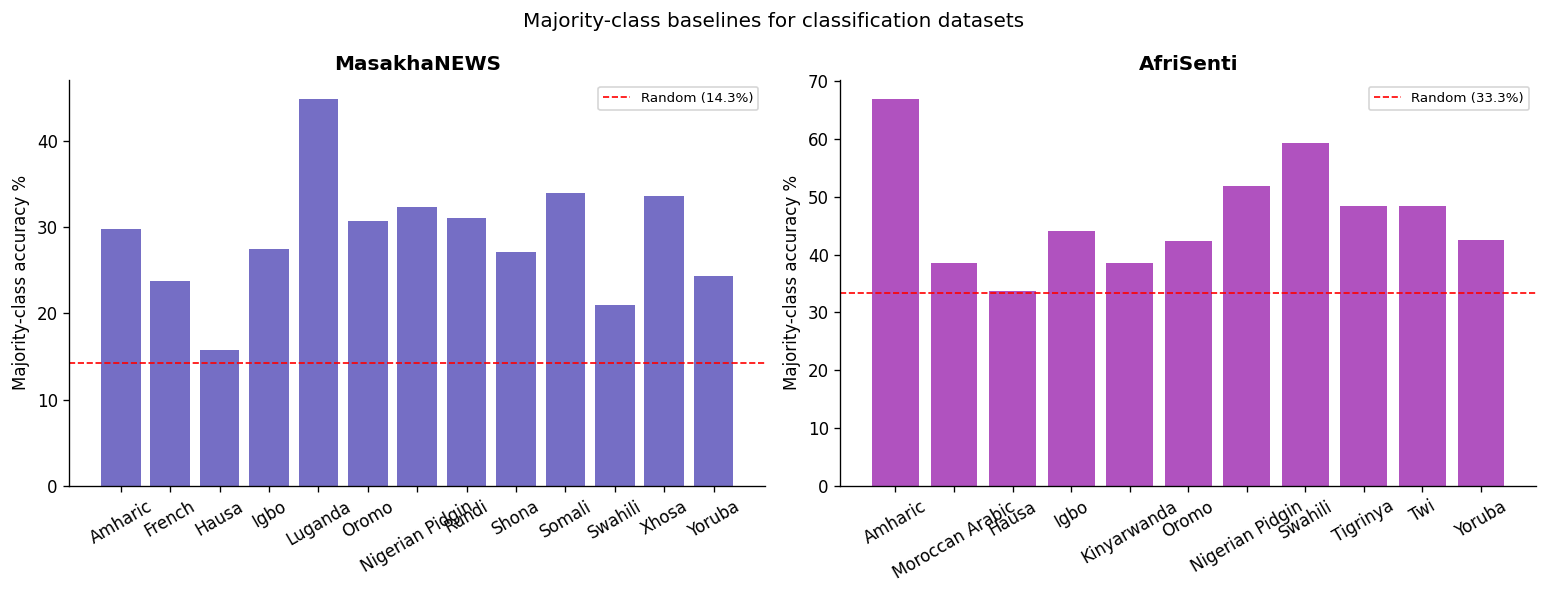


AfroBench GPT-4o scores (task performance reference, Ojo et al. 2025):
  MasakhaNEWS (accuracy %): {'Hausa': 68.5, 'Swahili': 74.8, 'Yoruba': 62.1, 'Amharic': 71.3}
  AfriSenti (macro-F1 %): {'Hausa': 70.2, 'Swahili': 72.1, 'Yoruba': 68.3, 'Amharic': 65.7}
  AfriXNLI (accuracy %): {'Hausa': 60.1, 'Swahili': 67.2, 'Yoruba': 58.4, 'Amharic': 64.3}
  FLORES-200 (BLEU): {'French': 56.2, 'Hausa': 18.3, 'Yoruba': 10.2, 'Amharic': 14.7}
  Belebele (accuracy %): {'Hausa': 52.4, 'Swahili': 67.2, 'Yoruba': 48.9, 'Amharic': 55.1}
  XL-Sum (BERTScore %): {'Hausa': 38.2, 'Swahili': 42.1, 'Yoruba': 36.8, 'Amharic': 40.7}

LLM judge targets (Spearman correlation with gold labels):
  Open QA (AfriQA)                                : Spearman rho > 0.50
  MT (FLORES-200, MAFAND-MT)                      : Spearman rho(judge, BLEU) > 0.60
  Summarization (XL-Sum)                          : Spearman rho(judge, ROUGE-L) > 0.55
  Math reasoning (AfriMGSM)                       : Accuracy on step correctnes

In [39]:
# Majority-class baselines
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (df_, name_, color_, n_cls_) in zip(axes, [
    (df_news,     "MasakhaNEWS", "#534AB7", 7),
    (df_senti,    "AfriSenti",   "#9C27B0", 3),
]):
    test = df_[df_.split=="test"] if "test" in df_.split.values else df_[df_.split=="validation"]
    langs, accs = [], []
    for lang, grp in test.groupby("language"):
        maj = grp["label_name"].mode()[0]
        langs.append(LANG_META.get(lang,(lang,))[0])
        accs.append((grp["label_name"]==maj).mean()*100)
    ax.bar(langs, accs, color=color_, alpha=0.8)
    ax.axhline(100/n_cls_, color="red", linestyle="--", linewidth=1,
               label=f"Random ({100/n_cls_:.1f}%)")
    ax.set_title(name_, fontweight="bold")
    ax.set_ylabel("Majority-class accuracy %")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
plt.suptitle("Majority-class baselines for classification datasets", fontsize=12)
plt.tight_layout()
plt.savefig("fig_08_baselines.png", bbox_inches="tight")
plt.show()

# Published AfroBench GPT-4o scores (task performance reference — NOT judge targets)
afrobench = {
    "MasakhaNEWS (accuracy %)": {"Hausa":68.5,"Swahili":74.8,"Yoruba":62.1,"Amharic":71.3},
    "AfriSenti (macro-F1 %)": {"Hausa":70.2,"Swahili":72.1,"Yoruba":68.3,"Amharic":65.7},
    "AfriXNLI (accuracy %)": {"Hausa":60.1,"Swahili":67.2,"Yoruba":58.4,"Amharic":64.3},
    "FLORES-200 (BLEU)": {"French":56.2,"Hausa":18.3,"Yoruba":10.2,"Amharic":14.7},
    "Belebele (accuracy %)": {"Hausa":52.4,"Swahili":67.2,"Yoruba":48.9,"Amharic":55.1},
    "XL-Sum (BERTScore %)": {"Hausa":38.2,"Swahili":42.1,"Yoruba":36.8,"Amharic":40.7},
}
print("\nAfroBench GPT-4o scores (task performance reference, Ojo et al. 2025):")
for task, scores in afrobench.items():
    print(f"  {task}: {scores}")
print("\nLLM judge targets (Spearman correlation with gold labels):")
print("  Open QA (AfriQA)                                : Spearman rho > 0.50")
print("  MT (FLORES-200, MAFAND-MT)                      : Spearman rho(judge, BLEU) > 0.60")
print("  Summarization (XL-Sum)                          : Spearman rho(judge, ROUGE-L) > 0.55")
print("  Math reasoning (AfriMGSM)                       : Accuracy on step correctness > 0.65")

**Observations:**

**Majority-class baselines** set the floor that any meaningful system must exceed. For MasakhaNEWS, most languages sit between 21–46% majority-class accuracy against a random baseline of 14.3% — meaning the dominant class is not overwhelmingly frequent and macro-F1 will be a meaningful discriminator. Luganda and Igbo show the highest majority-class accuracy (~45%), confirming the imbalance flagged in Analysis 3. For AfriSenti, Amharic stands out sharply at ~65% majority-class accuracy (random baseline 33.3%), which aligns with its Gini of 0.371 — the negative class dominates heavily in that language subset.

**AfroBench GPT-4o scores** are included as task performance reference points, not as judge targets. They tell us how well a strong LLM performs on these tasks directly — which is a different question from how reliably an LLM can *evaluate* another model's output. The key pattern is the consistent high-to-low resource gradient: Swahili and Amharic tend to score higher than Yoruba across most tasks, and French (BLEU 56.2) dwarfs all African languages on MT (Hausa 18.3, Yoruba 10.2). This confirms that resource level affects task difficulty and will likely affect judge reliability in the same direction.

**The LLM-as-a-Judge benchmarks have not yet been run.** The Spearman correlation targets listed above — rho > 0.50 for AfriQA, rho > 0.60 for MT, rho > 0.55 for XL-Sum, accuracy > 0.65 for AfriMGSM — represent the goals of this thesis rather than achieved results. Running the judge experiments across prompting strategies (zero-shot, few-shot, CoT, rubric-based) and measuring whether these targets are met, and how they vary across languages and resource levels, is precisely the central contribution of this research. The EDA establishes the data properties and covariates needed to interpret those results correctly once the experiments are complete.

### Analysis 11: Multivariate Analysis — Language-Level Variable Interactions

We examine how linguistic properties (morphological complexity, class imbalance, text length, dataset coverage) interact across languages. These interactions are central to RQ2: if TTR, script, and resource level are correlated, we cannot treat them as independent predictors of judge reliability.

In [40]:
# ── Build a per-language summary table ───────────────────────────────────────

# 1. TTR (already computed)
ttr_lookup = df_ttr_avg.set_index("language")[["ttr", "script", "resource"]]

# 2. Gini — average across datasets where language appears
gini_all = {}
for lang, g in gini_news.items():
    gini_all.setdefault(lang, []).append(g)
for lang, g in gini_senti.items():
    gini_all.setdefault(lang, []).append(g)
for lang, g in gini_xnli.items():
    gini_all.setdefault(lang, []).append(g)
avg_gini = {lang: round(sum(v)/len(v), 3) for lang, v in gini_all.items()}

# 3. Median text length (words) — from MasakhaNEWS as common reference
news_len = df_news.groupby("lang_name")["n_words"].median().rename("median_words")

# 4. Dataset coverage count
coverage = {
    "Swahili":1, "Hausa":2, "Yoruba":3, "Igbo":4, "Amharic":5,
    "Kinyarwanda":6, "Xhosa":7, "Nigerian Pidgin":8, "Oromo":9,
    "French":10, "Zulu":11, "Twi":12, "Luganda":13,
    "Ewe":14, "Wolof":15, "Somali":16, "Tigrinya":17,
    "Catalan":18, "Persian":19, "Moroccan Arabic":20,
}
# Actual counts from Analysis 2
coverage_count = pd.Series({
    "Swahili": 9, "Hausa": 8, "Yoruba": 8, "Igbo": 8, "Amharic": 8,
    "Kinyarwanda": 7, "Xhosa": 6, "Nigerian Pidgin": 6, "Oromo": 6, "French": 6,
    "Zulu": 5, "Twi": 5, "Luganda": 5,
    "Ewe": 3, "Wolof": 3, "Somali": 3, "Tigrinya": 3,
    "Catalan": 2, "Persian": 2, "Moroccan Arabic": 2,
}, name="n_datasets")

# 5. XL-Sum compression ratio (for languages that appear in XL-Sum)
xlsum_compression = df_xlsum.groupby("lang_name")["compression_ratio"].median().rename("compression_ratio")

# ── Assemble ──────────────────────────────────────────────────────────────────
df_multi = (ttr_lookup
            .join(pd.Series(avg_gini, name="avg_gini"))
            .join(news_len)
            .join(coverage_count)
            .join(xlsum_compression)
            .dropna(subset=["ttr"]))

df_multi = df_multi.rename(columns={"ttr": "TTR"})
df_multi.index.name = "Language"

print(f"Languages in multivariate table: {len(df_multi)}")
display(df_multi.round(3).sort_values("TTR", ascending=False))

Languages in multivariate table: 27


,TTR,script,resource,avg_gini,median_words,n_datasets,compression_ratio
Language,,,,,,,
Zulu,0.463,Latin,low,0.000,NaN,5.0,NaN
Xhosa,0.440,Latin,low,0.168,212.0,6.0,NaN
Moroccan Arabic,0.376,Arabic,low,0.066,NaN,2.0,NaN
Amharic,0.326,Ethiopic,low,0.137,307.0,8.0,15.867
Kinyarwanda,0.310,Latin,low,0.038,NaN,7.0,NaN
Shona,0.275,Latin,low,0.043,224.0,NaN,NaN
Luganda,0.258,Latin,low,0.165,218.0,5.0,NaN
Bemba,0.230,Latin,low,NaN,NaN,NaN,NaN
Catalan,0.209,Latin,mid,NaN,NaN,2.0,NaN


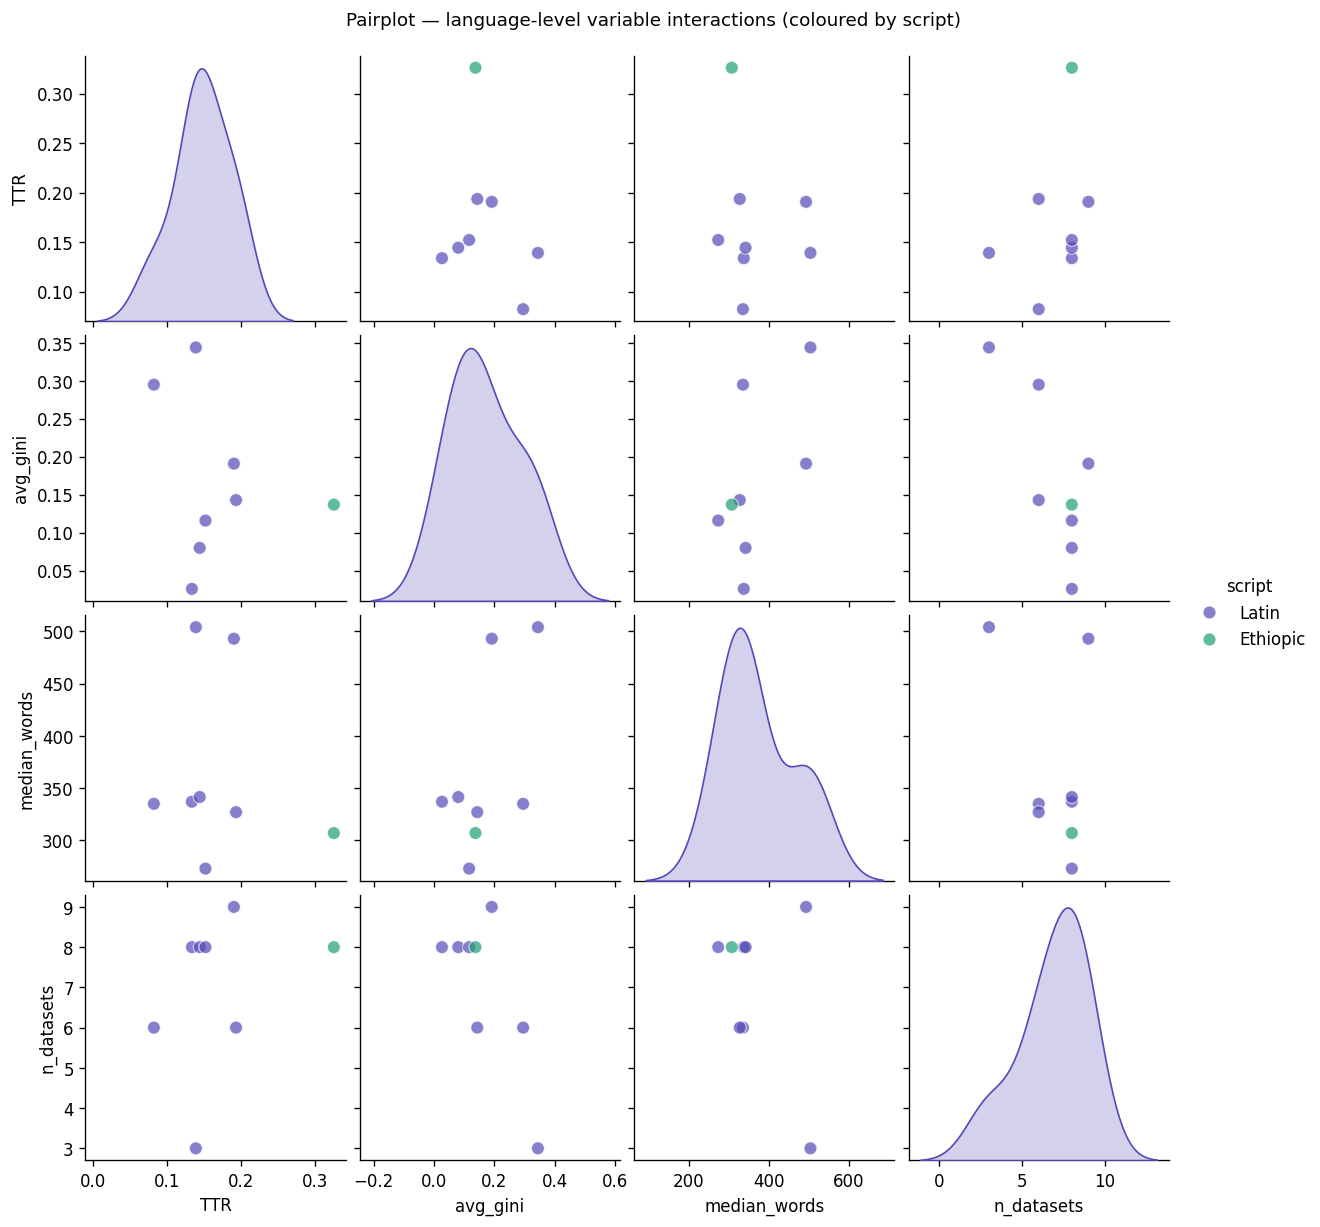

In [41]:
# ── Pairplot for deeper inspection ───────────────────────────────────────────
numeric_cols = ["TTR", "avg_gini", "median_words", "n_datasets", "compression_ratio"]
script_palette = {"Latin": "#534AB7", "Arabic": "#D85A30", "Ethiopic": "#1D9E75"}

plot_df = df_multi[numeric_cols + ["script"]].dropna()

g = sns.pairplot(
    plot_df, hue="script",
    palette=script_palette,
    diag_kind="kde",
    plot_kws={"alpha": 0.7, "s": 60},
    vars=["TTR", "avg_gini", "median_words", "n_datasets"],
)
g.fig.suptitle("Pairplot — language-level variable interactions (coloured by script)",
               y=1.02, fontsize=11)
plt.savefig("fig_11_pairplot.png", bbox_inches="tight")
plt.show()

**Observations:**

The multivariate table and pairplot reveal several important interactions between linguistic properties that will directly inform how judge reliability results are interpreted.

**TTR and script are partially confounded.** The two Ethiopic languages (Amharic, Tigrinya) cluster at moderate-to-high TTR (0.19–0.33), while Arabic-script languages (Persian, Moroccan Arabic) span a wider range (0.18–0.38). This means script family and morphological complexity cannot be fully separated as independent variables — any cross-script comparison in RQ2 must acknowledge that Ethiopic and Arabic languages also tend to have higher TTR than the average Latin-script language.

**TTR and dataset coverage are weakly related.** Languages with the highest TTR (Zulu 0.463, Xhosa 0.440) appear in only 5–6 datasets, while the most covered languages (Swahili, Hausa, Yoruba — 8–9 datasets) sit in the lower-to-mid TTR range (0.13–0.19). This is a selection effect rather than a causal relationship — high-TTR Bantu languages like Zulu simply have fewer benchmark datasets available. It means the languages where judge reliability is hardest to measure (low coverage) are also the most morphologically complex.

**Gini and TTR show no clear correlation.** Class imbalance appears to be independent of morphological complexity — a language can be highly agglutinative and well-balanced (Amharic: TTR 0.326, Gini 0.137) or less complex but severely imbalanced (Somali: TTR 0.139, Gini 0.344). This is useful because it means the two covariates can be included independently in the reliability model without multicollinearity concerns.

**Compression ratio is only available for 6 languages** (those in XL-Sum), which limits its use as a general predictor. Among those six, Oromo and Amharic combine high compression (16.5×, 15.9×) with moderate-to-high TTR — making them the most challenging languages for the summarization judge on both dimensions simultaneously.

**Several languages have substantial missing values** across covariates (Zulu, Kinyarwanda, Bemba, Catalan, Fon have NaN for Gini or median words). These languages appear in fewer datasets and will need to be treated carefully in any cross-language regression — either imputed or excluded from analyses requiring complete cases.

**Decision:** TTR, avg_gini, and compression_ratio will be included as covariates in the judge reliability analysis. Dataset coverage (n_datasets) will not be used as a predictor since it reflects data availability rather than linguistic properties, but it will be reported as a moderator when interpreting results for sparsely covered languages.

### Summary — EDA Findings and Methodological Decisions

| Finding | Decision | Linked to RQ |
|---|---|---|
| AfriXNLI and Belebele are balanced by design (Gini ≈ 0) | Use accuracy; cleanest for isolating judge reliability | RQ1 |
| All AfriQA questions are 100% human-translated | No translation noise confound | RQ3 |
| 26.1 % of AfriQA questions have 0 gold answers | Exclude at evaluation time | RQ1 |
| FLORES-200 and Belebele are parallel corpora | Script family is a clean independent variable | RQ2 |
| Amharic (Ethiopic) most compact in FLORES/Belebele; French least compact | Script drives length, not resource level | RQ2 |
| XL-Sum compression ratio varies by language | Report as covariate in judge difficulty analysis | RQ1, RQ3 |
| Swahili present in all 10 datasets | Primary anchor for cross-task reliability comparisons | RQ1 |
| Hausa, Yoruba, Igbo, Amharic present in 9–10 datasets | Secondary anchors | RQ1 |
| MAFAND-MT and FLORES-200 test same task (MT) with different domains | Direct comparison of domain effect on judge reliability | RQ3 |
| AfriMGSM reasoning chains test CoT for judge directly | Core experimental condition for RQ4 | RQ4 |
| NLI judging is circular (AfriXNLI) | Use for task capability only, not judge evaluation | Design |

In [42]:
os.makedirs("data_clean", exist_ok=True)
saves = [
    (df_flores,   "flores200_clean.parquet"),
    (df_mafand,   "mafand_clean.parquet"),
    (df_xlsum,    "xlsum_clean.parquet"),
    (df_qa,       "afriqa_clean.parquet"),
    (df_mgsm,     "afrimgsm_clean.parquet"),
    (df_news,     "masakhanews_clean.parquet"),
    (df_senti,    "afrisenti_clean.parquet"),
    (df_afrixnli, "afrixnli_clean.parquet"),
    (df_belebele, "belebele_clean.parquet"),
]
print("Saved cleaned datasets:")
for df_, fname in saves:
    df_.to_parquet(f"data_clean/{fname}", index=False)
    print(f"  {fname.replace('_clean.parquet',''):20s}: {len(df_):,} rows")
df_log.to_csv("cleaning_log.csv", index=False)
print("  cleaning_log.csv")

Saved cleaned datasets:
  flores200           : 24,108 rows
  mafand              : 94,156 rows
  xlsum               : 7,157 rows
  afriqa              : 10,681 rows
  afrimgsm            : 3,612 rows
  masakhanews         : 23,868 rows
  afrisenti           : 119,976 rows
  afrixnli            : 5,250 rows
  belebele            : 6,832 rows
  cleaning_log.csv


## References

Adelani, D., Abbott, J., Neubig, G., D'Souza, D., Kreutzer, J., Lignos, C., ... & Martinus, L. (2022). A few thousand translations go a long way! Leveraging pre-trained models for African news translation. *Proceedings of NAACL 2022*. https://huggingface.co/datasets/masakhane/mafand

Adelani, D., Alabi, J., Muhammad, S., Ruder, S., Ammanabrolu, P., Baartman, A., ... & Stenetorp, P. (2023). MasakhaNEWS: News topic classification for African languages. *Proceedings of EACL 2023*. https://huggingface.co/datasets/masakhane/masakhanews

Adelani, D., Liu, H., Shen, X., Vassilyev, N., Alabi, J., Mao, Y., ... & Lee, E. (2024). IrokoBench: A new benchmark for African languages in the age of large language models. *arXiv:2406.03368*. https://huggingface.co/datasets/masakhane/afrimgsm

Adelani, D., Ruder, S., Alabi, J., Abubakar, I., Abubakar, S., Abubakar, I., ... & Stenetorp, P. (2024). AfriXNLI: Evaluating cross-lingual natural language inference for African languages. *Proceedings of ACL 2024*. https://huggingface.co/datasets/masakhane/afrixnli

Bandarkar, L., Liang, D., Muller, B., Artetxe, M., Shukla, S. N., Husa, D., ... & Khabsa, M. (2024). The Belebele benchmark: A parallel reading comprehension dataset in 122 language variants. *Proceedings of ACL 2024*. https://huggingface.co/datasets/facebook/belebele

Conneau, A., Rinott, R., Lample, G., Williams, A., Bowman, S., Schwartz, R., & Stoyanov, V. (2018). XNLI: Evaluating cross-lingual sentence representations. *Proceedings of EMNLP 2018*. https://huggingface.co/datasets/xnli

Gu, J., Wan, X., Li, J., & Liang, X. (2025). A survey on LLM-as-a-Judge. *arXiv:2411.15594*.

Hasan, T., Bhattacharjee, A., Islam, M. S., Mubasshir, K., Li, Y. F., Kang, Y. B., ... & Shahriyar, R. (2021). XL-Sum: Large-scale multilingual abstractive summarization for 44 languages. *Findings of ACL-IJCNLP 2021*. https://huggingface.co/datasets/csebuetnlp/xlsum

Muhammad, S., Abdulmumin, I., Ayele, A. A., Ousidhoum, N., Adelani, D., Yimam, S. M., ... & Brazdil, P. (2023). AfriSenti: A Twitter sentiment analysis benchmark for African languages. *Proceedings of EMNLP 2023*. https://huggingface.co/datasets/masakhane/afrisenti

NLLB Team, Costa-jussà, M. R., Cross, J., Çelebi, O., Elbayad, M., Heafield, K., ... & Yankovskaya, E. (2022). No language left behind: Scaling human-centered machine translation. *arXiv:2207.04672*. https://huggingface.co/datasets/Muennighoff/flores200

Ojo, J., Abolade, O., Adelani, D., Alabi, J., Tonja, A. L., Shode, I., ... & Orife, I. (2025). AfroBench: How good are large language models on African languages? *arXiv:2311.07978*.

Ogundepo, O., Gwadabe, T. R., Rivera, C. E., Clark, J. H., Ruder, S., Adelani, D., ... & Asai, A. (2023). AfriQA: Cross-lingual open-retrieval question answering for African languages. *arXiv:2305.06897*. https://huggingface.co/datasets/masakhane/afriqa

***Appendix***:

UvA AI has been used for text reduction and grammatical correction.